<cell_type>markdown</cell_type># Experiment 1a vs Experiment 2a - W-estimate skill comparison (Ri5 model)

Same comparison as `compare_exp_1_2`, but for the `a` variants, which draw truth
from the `oct2012_TP6Vel_3month_Ri5` run instead of `oct2012_3month_transp_cons`.

Overlays the summary figures from **experiment_1a** and **experiment_2a**, which are
identical except that experiment_2a passes `extrapolate_to_surface=True` to
`compute_w_planefit` (so its integrated w reaches the surface; its depth grid runs
0 -> -70 m instead of -8 -> -70 m).

Reproduces Figures **2a-2d** (skill vs array width) and **5a-5d** (skill vs depth)
from `experiment_*a/summary.ipynb`, plotting both experiments on the same axes.

Encoding used throughout:

- **color** = the within-method knob (cell center latitude / gliders-per-cell for
  2a-c / 5a-c; **cell shape** - diamond / hexagon / square - for 2d / 5d).
- **linestyle + marker fill** = experiment: **exp1a = solid, filled marker**;
  **exp2a = dashed, open marker**.
- **marker shape** (2d / 5d only) = cell height (o = 1deg tall, ^ = 2deg tall).

Everything is read from `experiment_*a/data/`; figures are written to this folder.
Run in place after both experiments have populated their `data/`.

In [1]:
import os, sys
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

REPO = "/home/edavenport/analysis/tpose24-osse"
sys.path.insert(0, REPO)
import summary_fig_tools as sft

OUTDIR = os.path.join(REPO, "compare_exp_1a_2a"); os.makedirs(OUTDIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 120
sft.apply_style()

EXP_ROOT = {1: os.path.join(REPO, "experiment_1a"), 2: os.path.join(REPO, "experiment_2a")}
M = {e: pd.read_csv(os.path.join(EXP_ROOT[e], "data", "metrics.csv")) for e in (1, 2)}

def load_cell(exp, row):
    """Open the saved w_est/w_model/bias arrays for one metrics row of an experiment."""
    return xr.open_dataset(os.path.join(EXP_ROOT[exp], row.nc_path))

print({e: len(M[e]) for e in (1, 2)})

{1: 120, 2: 120}


In [2]:
# Shared style / helpers now live in summary_fig_tools (imported as sft).

## Figures 2a-2d - skill vs array width, exp1 vs exp2

One figure per method. Panels 1-2: normalized error and correlation vs glider
offset, with exp1 (solid, filled) and exp2 (dashed, open) overlaid; color is the
within-method knob. Panel 4: the fixed platform layout (identical for both
experiments).

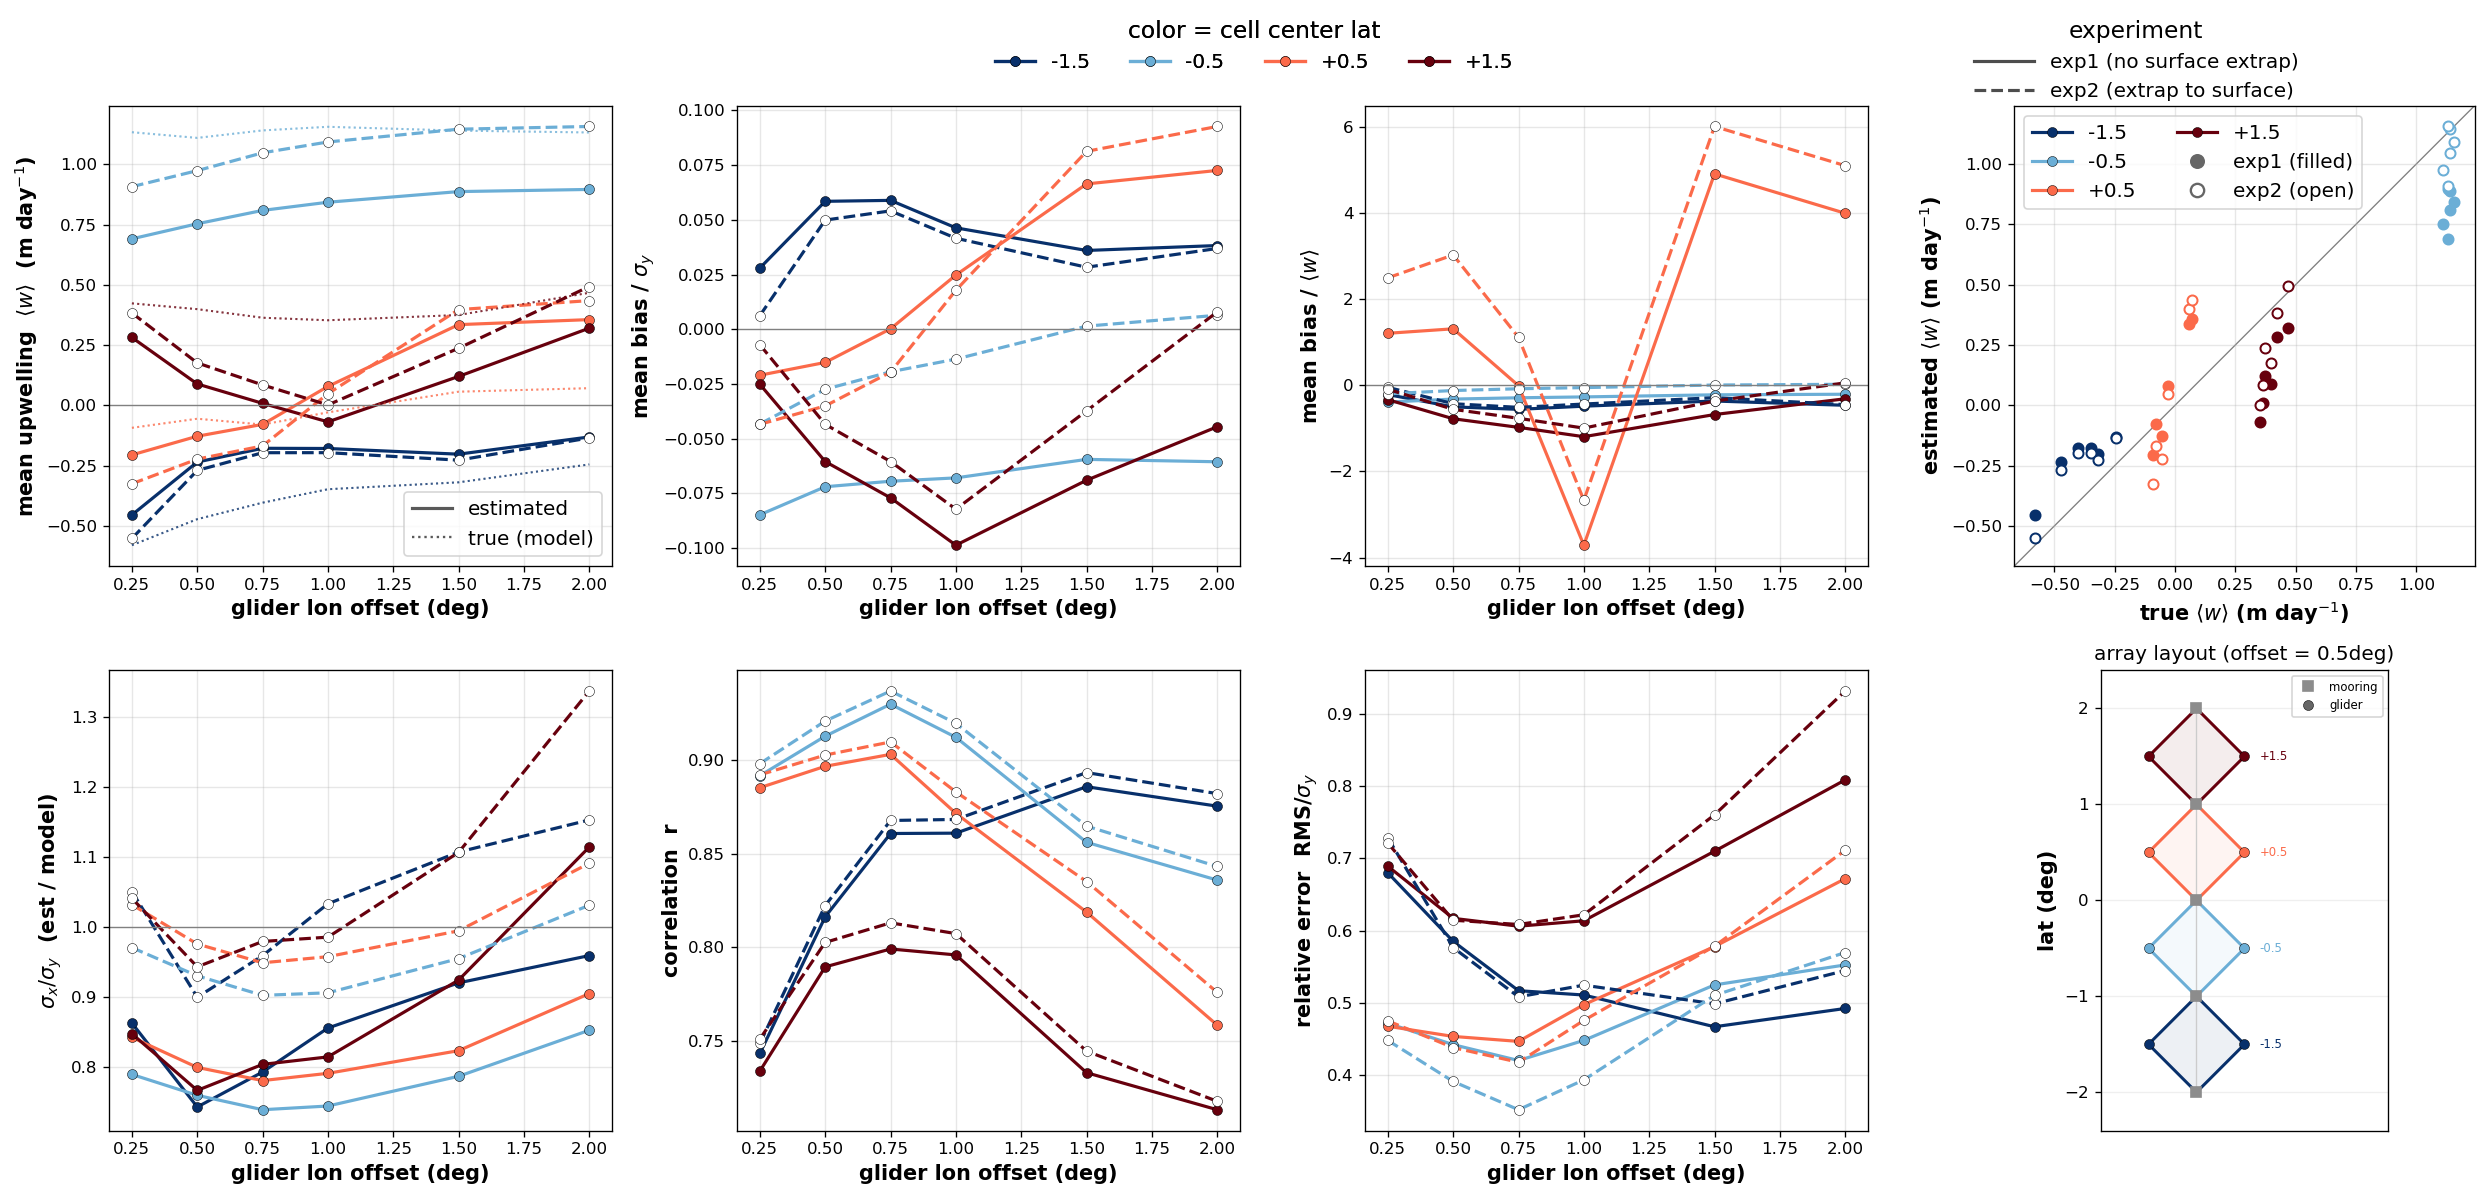

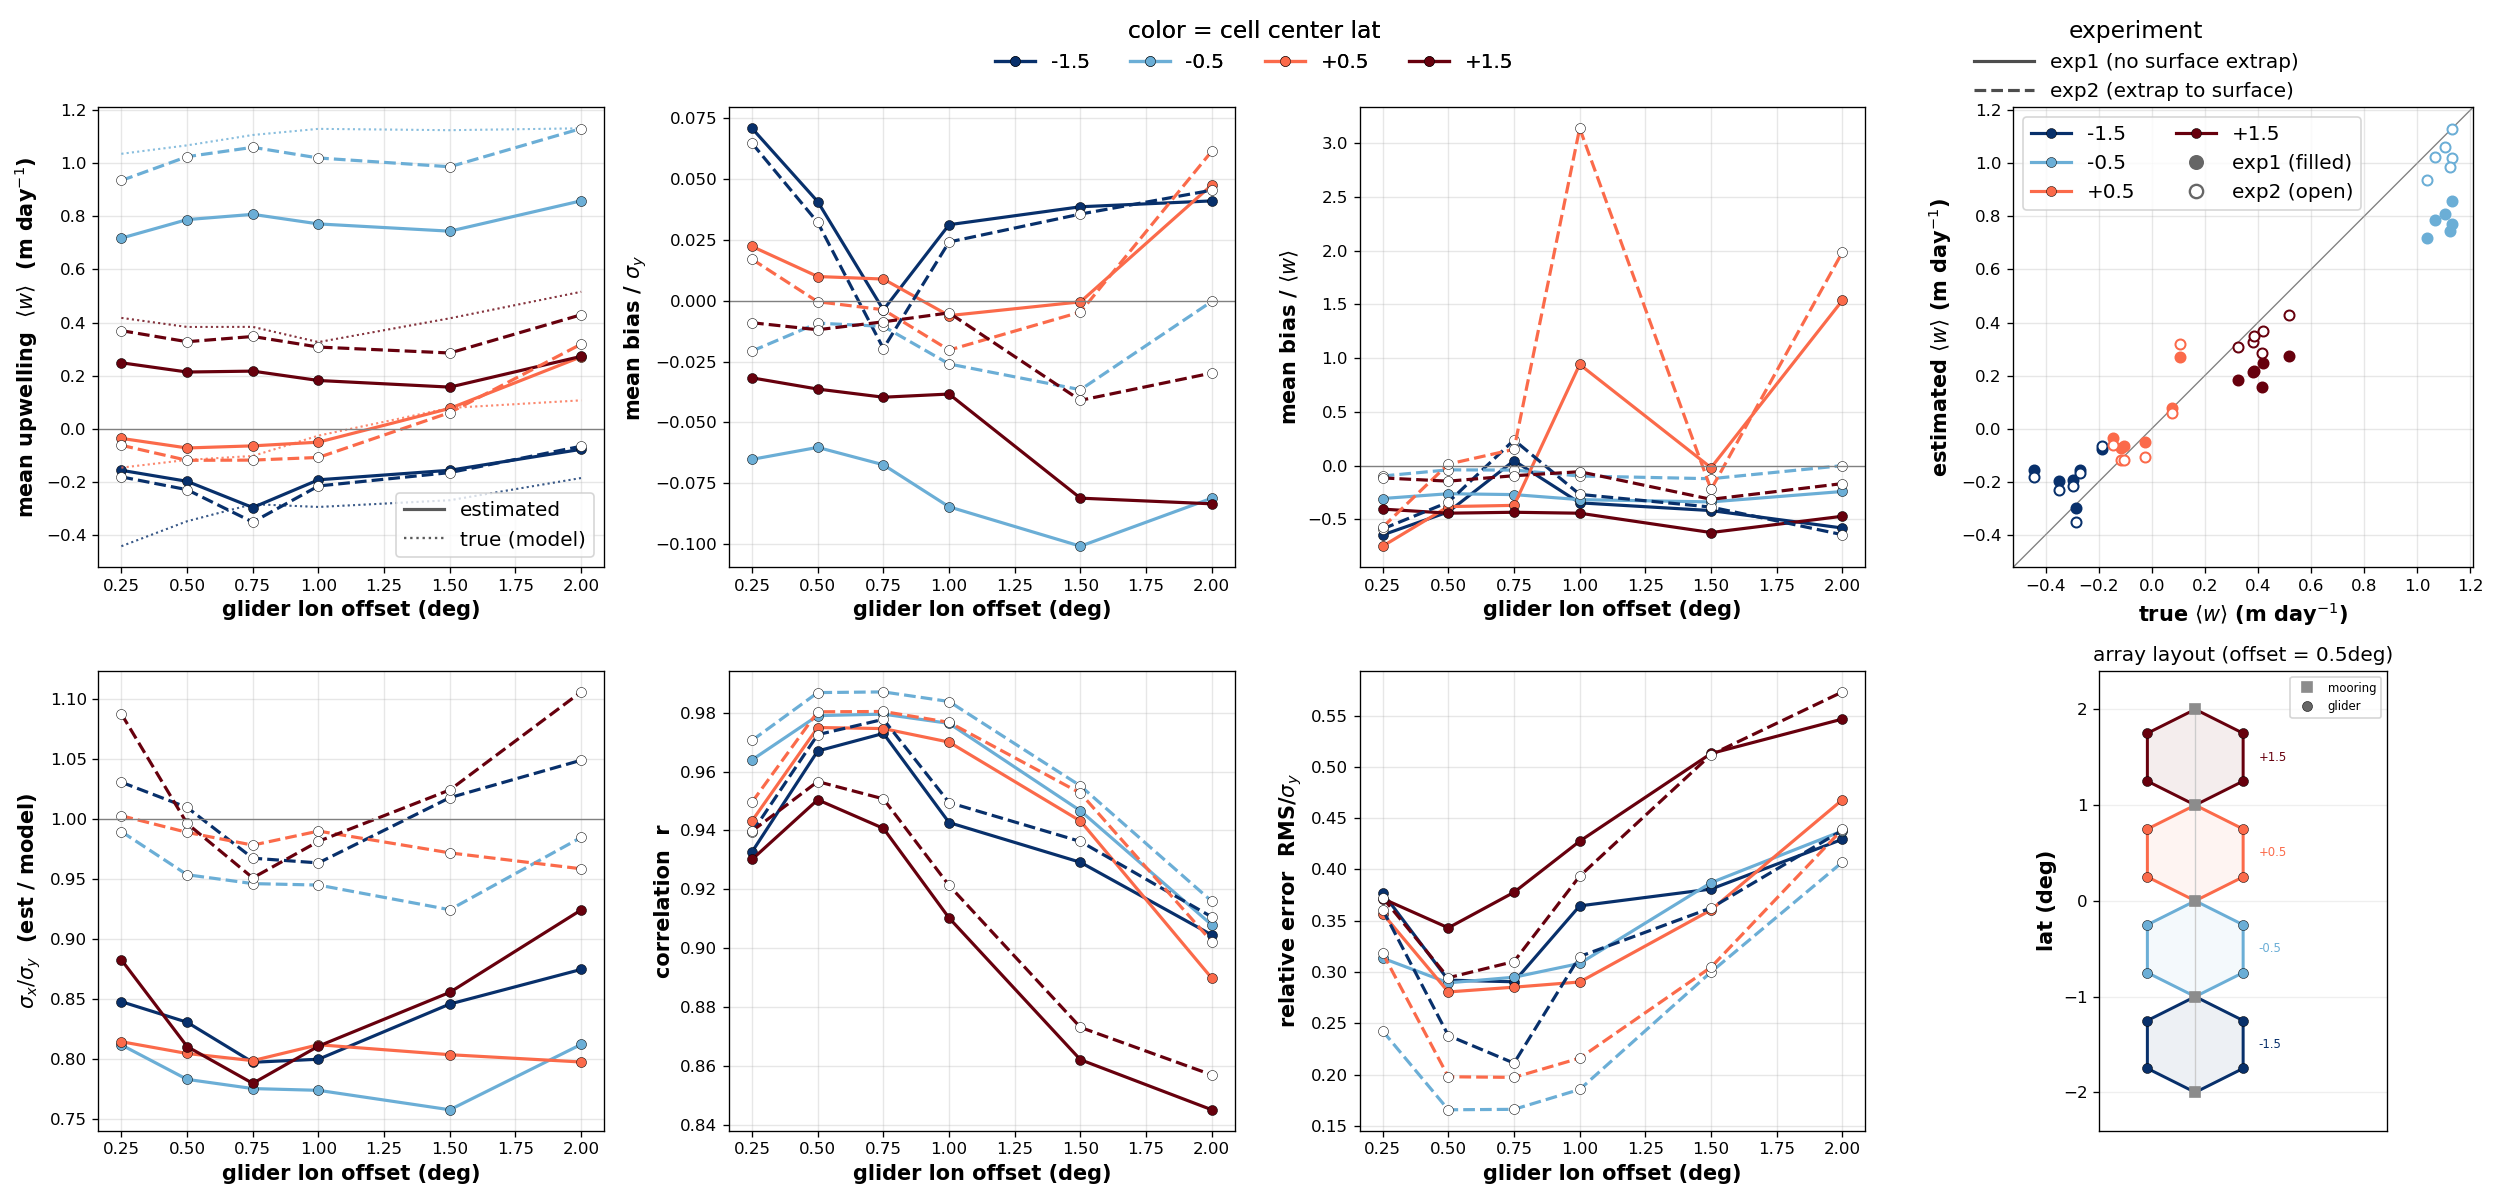

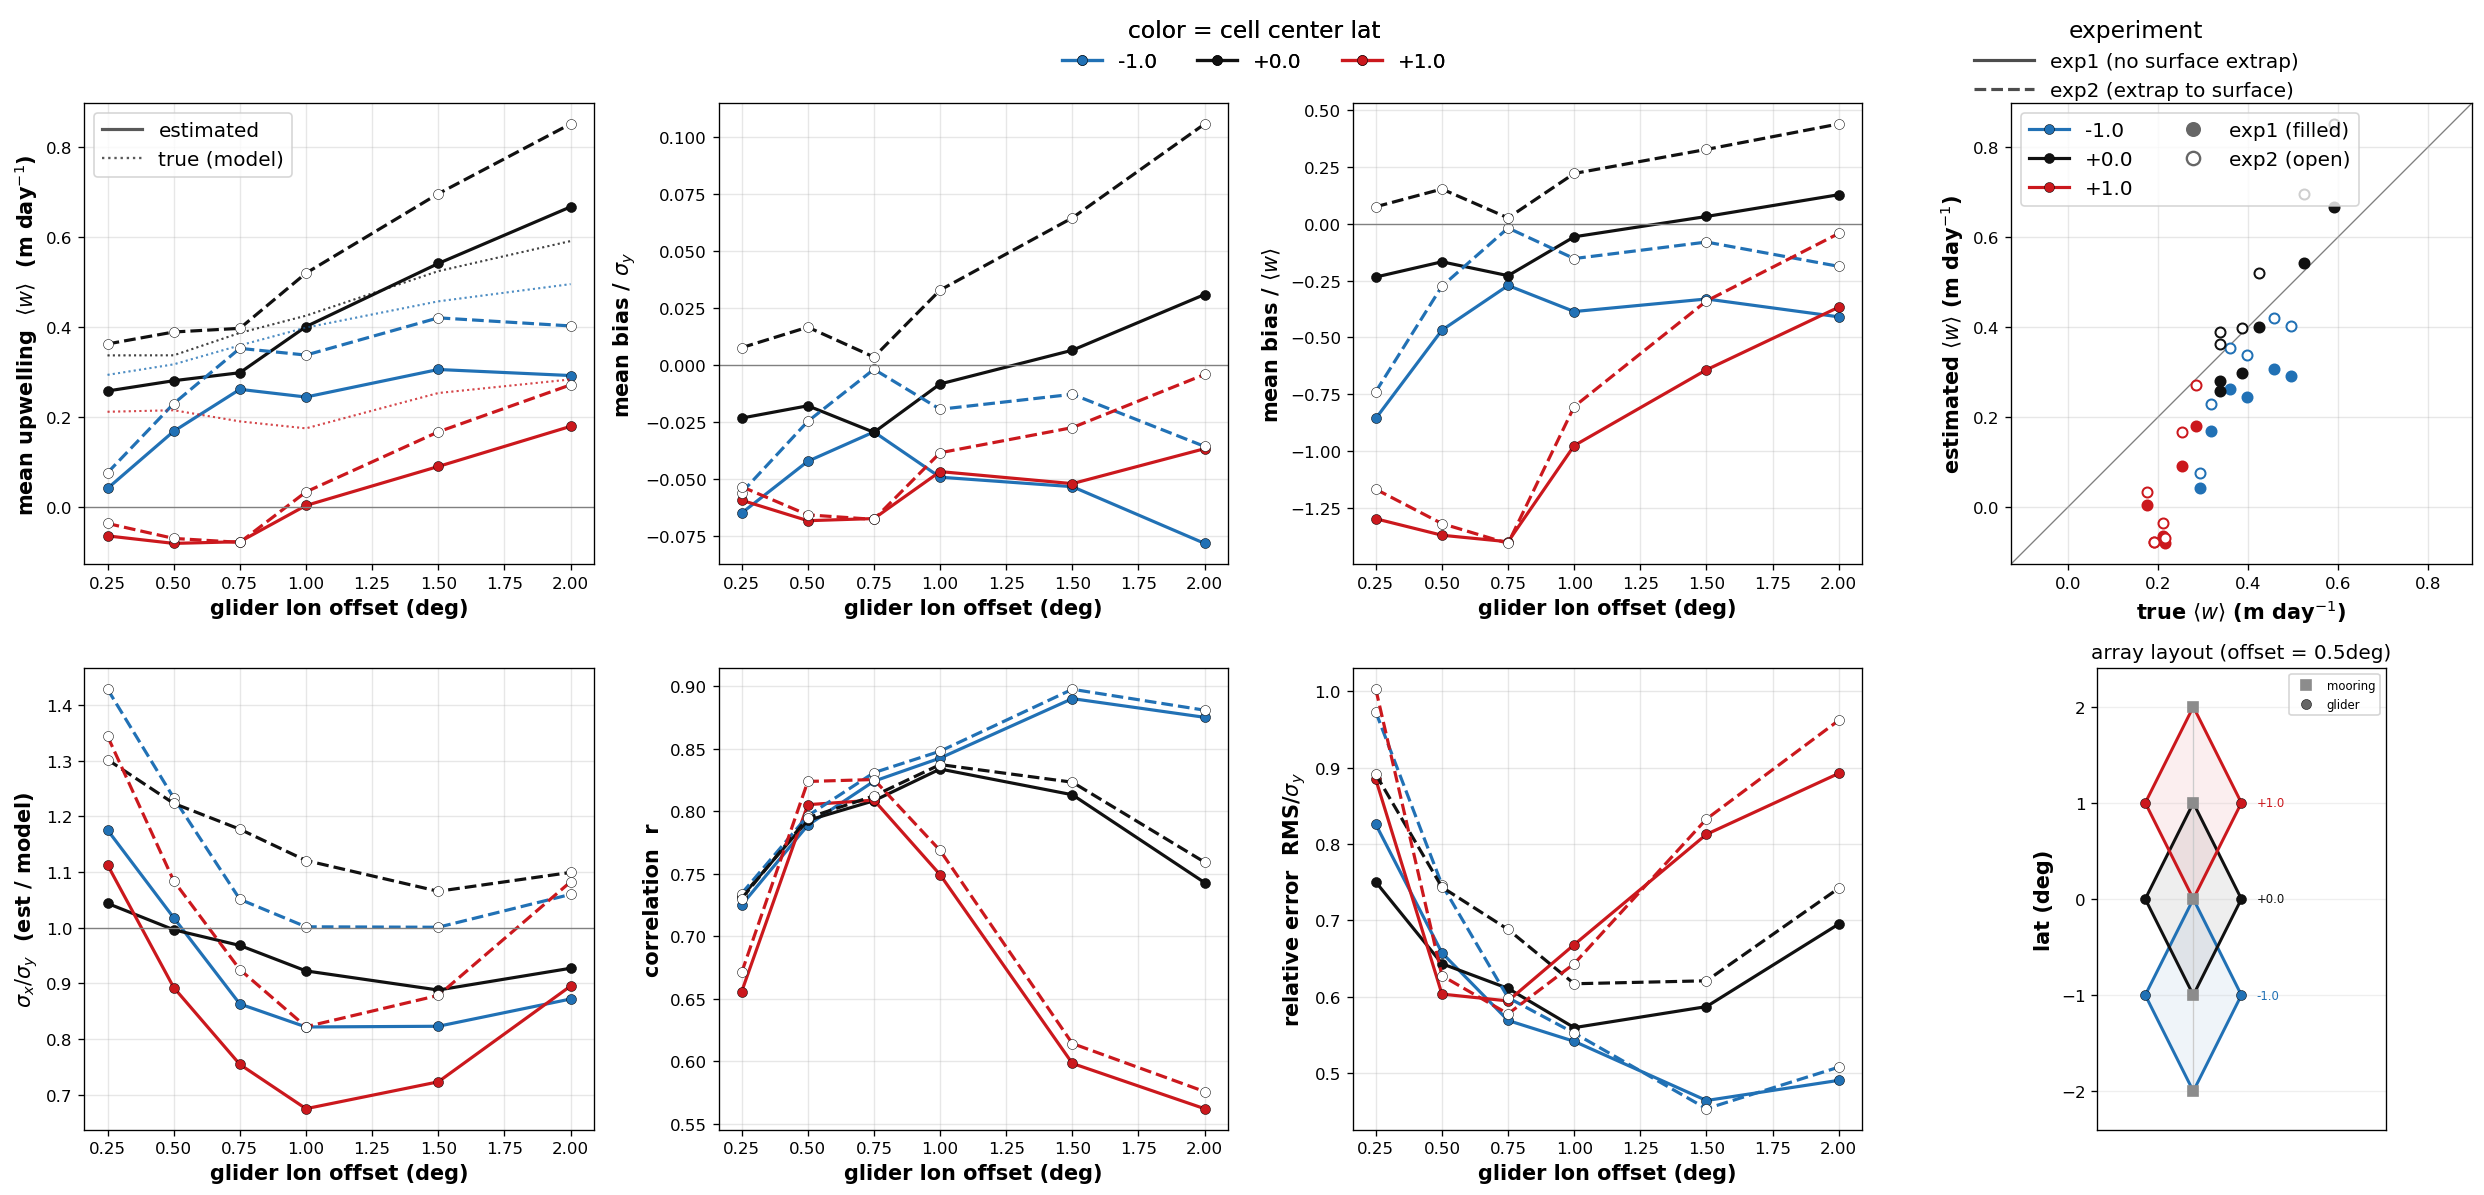

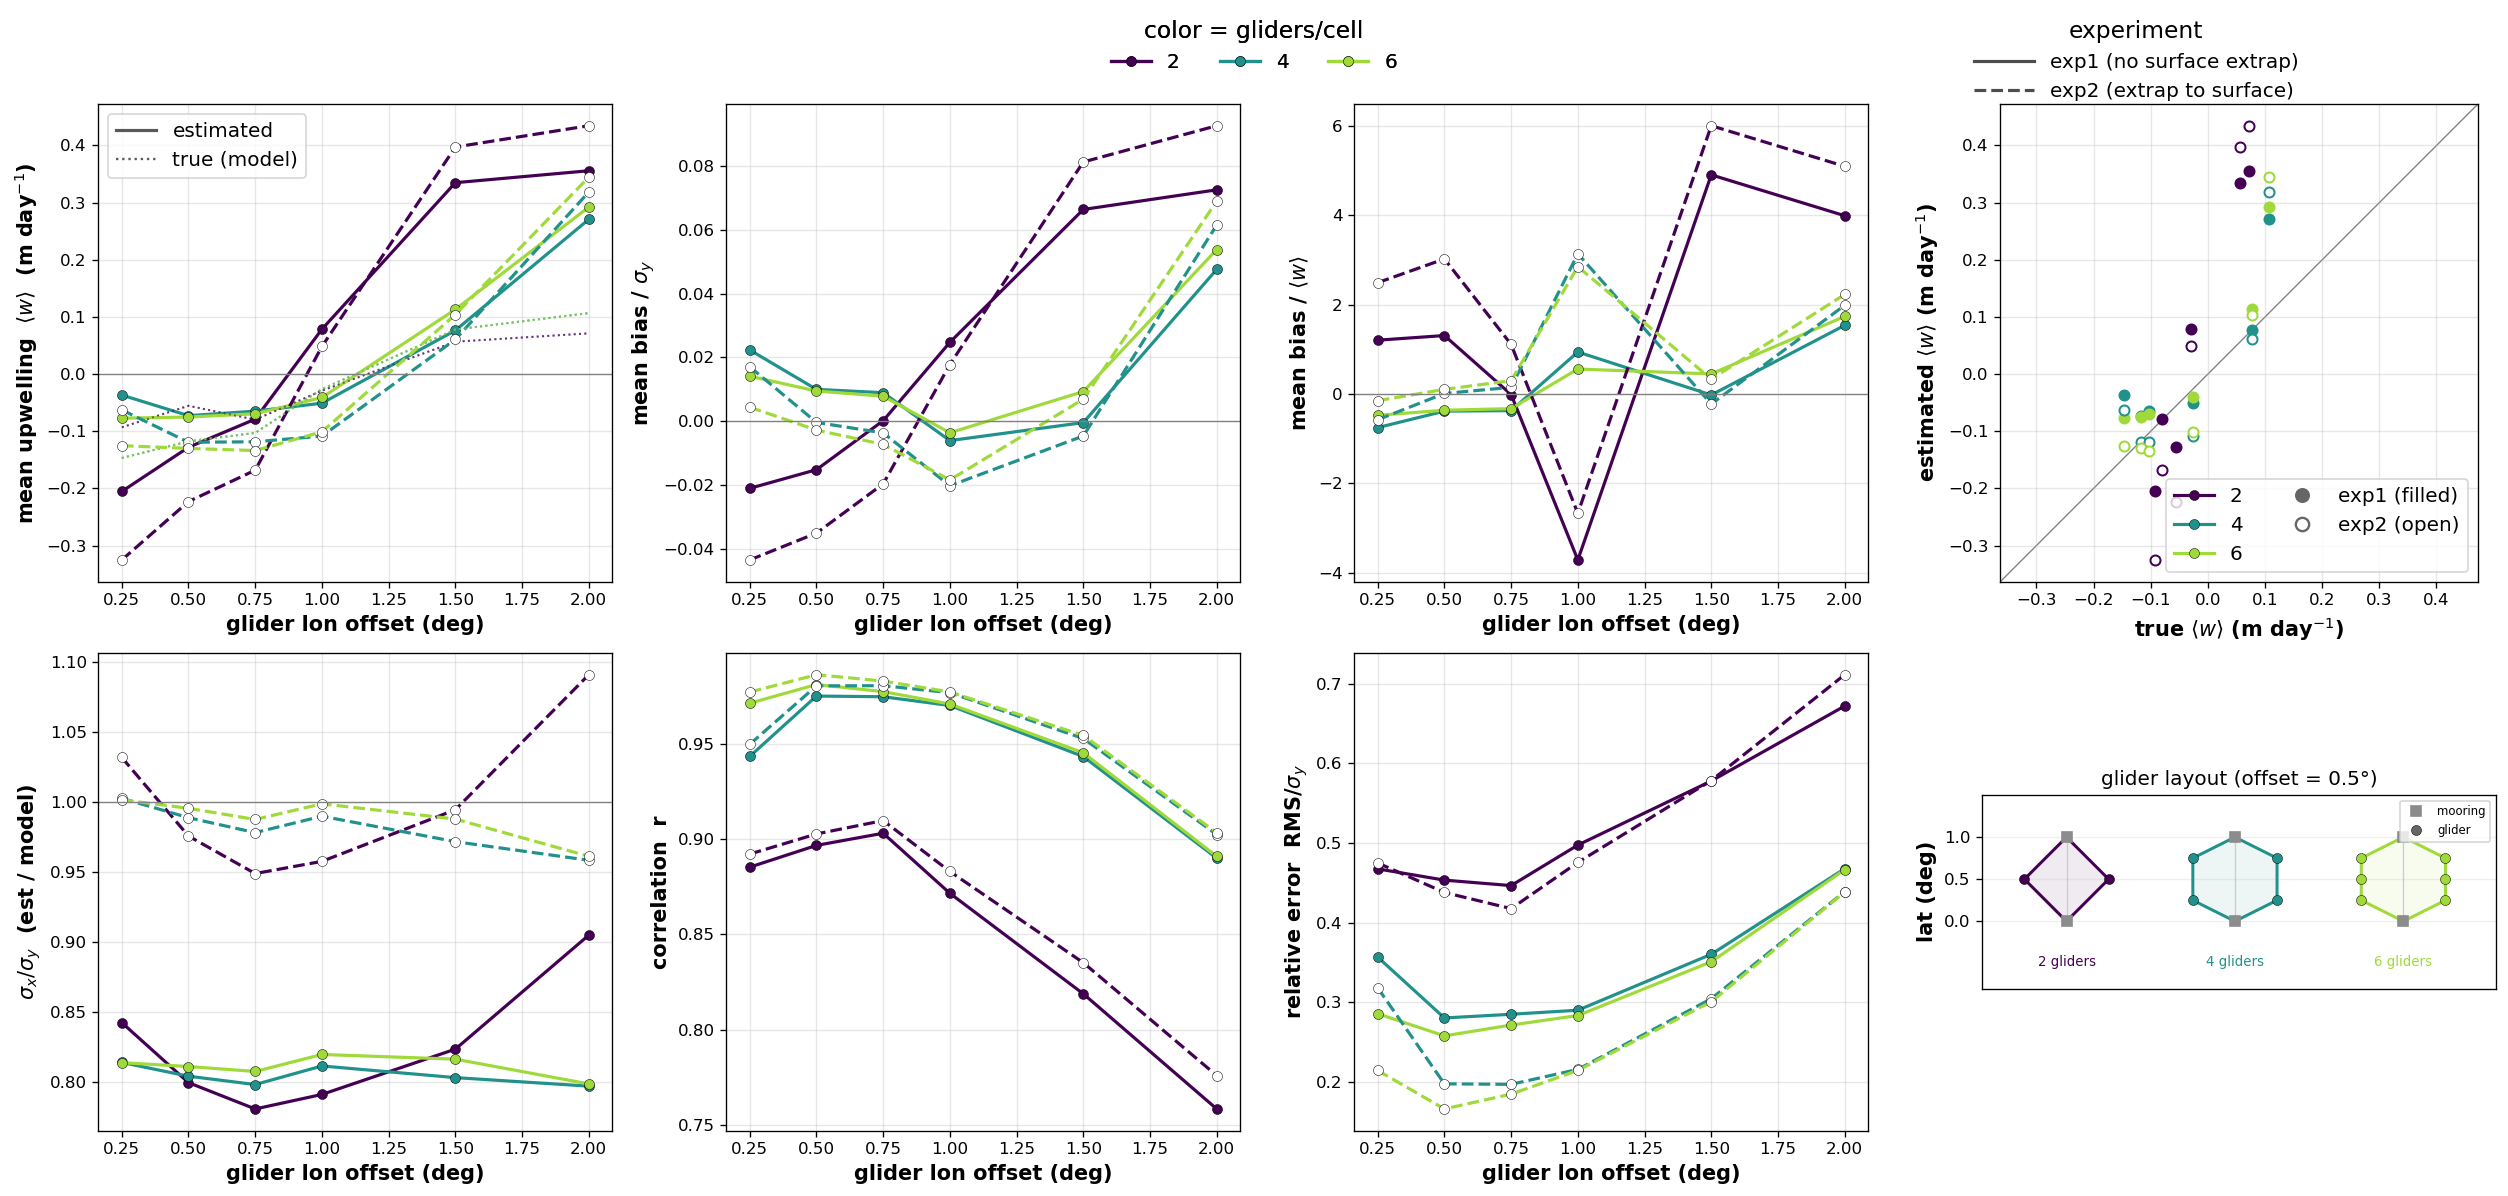

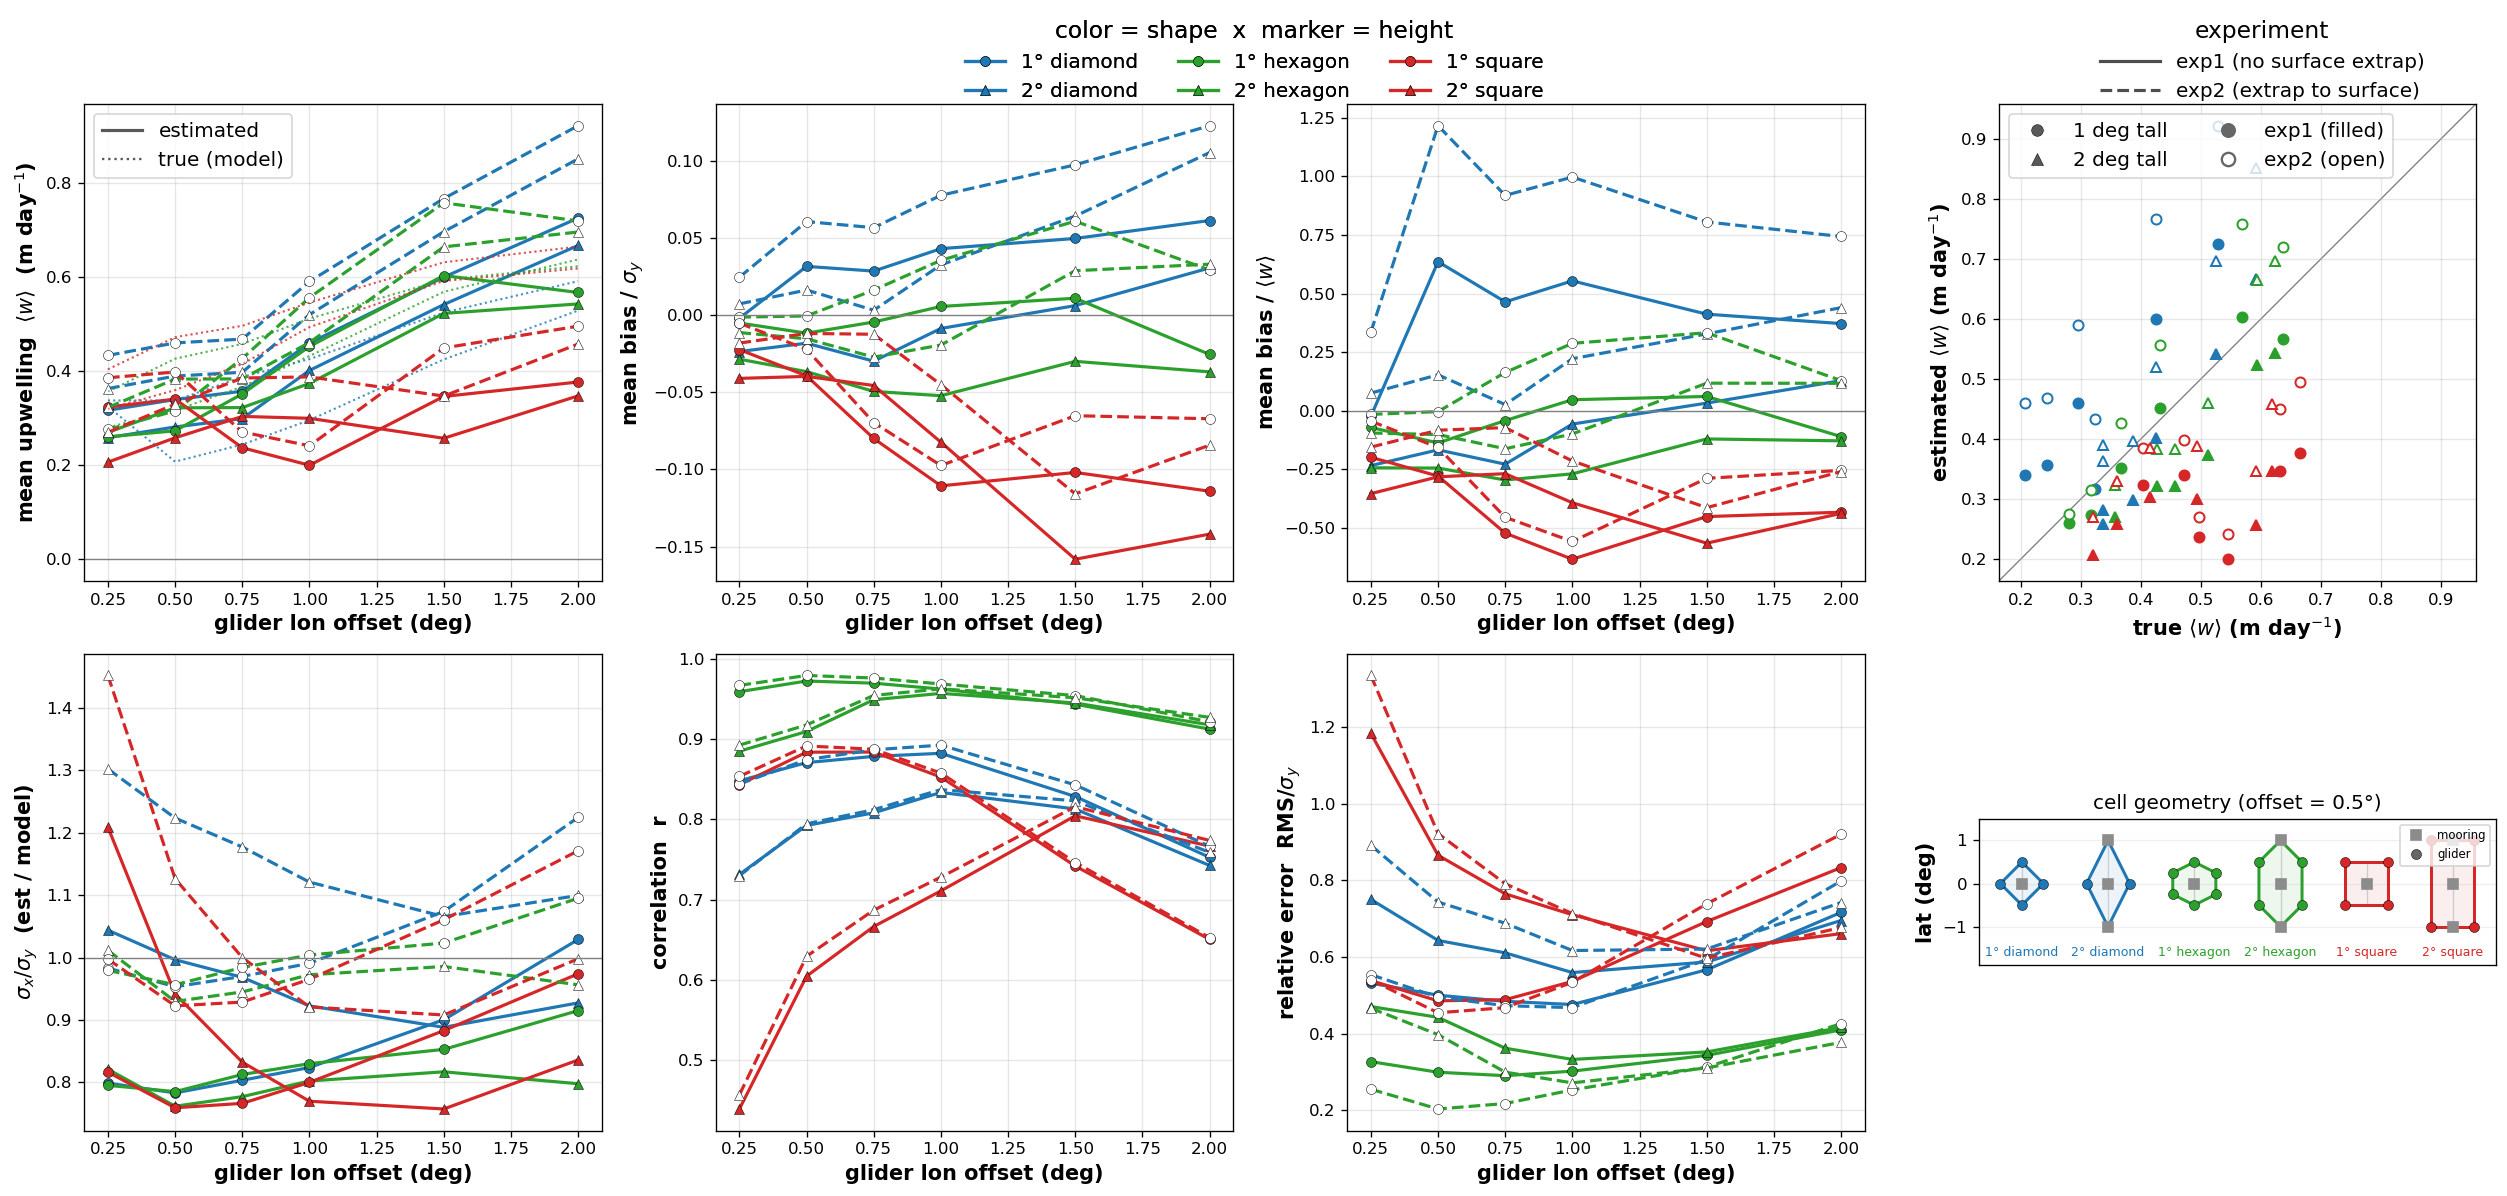

In [3]:
sft.make_fig2abcd_compare(M, OUTDIR)

In [4]:
# fig2d is drawn by make_fig2abcd_compare above.

## Figures 5a-5d - skill vs depth, exp1 vs exp2

Depth-resolved skill at a fixed glider offset (`DEPTH_WIDTH = 1.0deg` for 5a-5c,
`0.5deg` for 5d), one figure per method. Panels: normalized error, correlation,
fractional mean bias (⟨w_est⟩−⟨w_model⟩)/⟨w_model⟩ (masked at the mean's
zero-crossings), absolute RMS (colored) vs signal std (gray), and the mean w
profile itself — estimate (colored) vs model truth (gray). exp1 = solid/filled,
exp2 = dashed/open. Because exp2 extrapolates to the surface, its profiles extend
above -8 m up to 0 m.

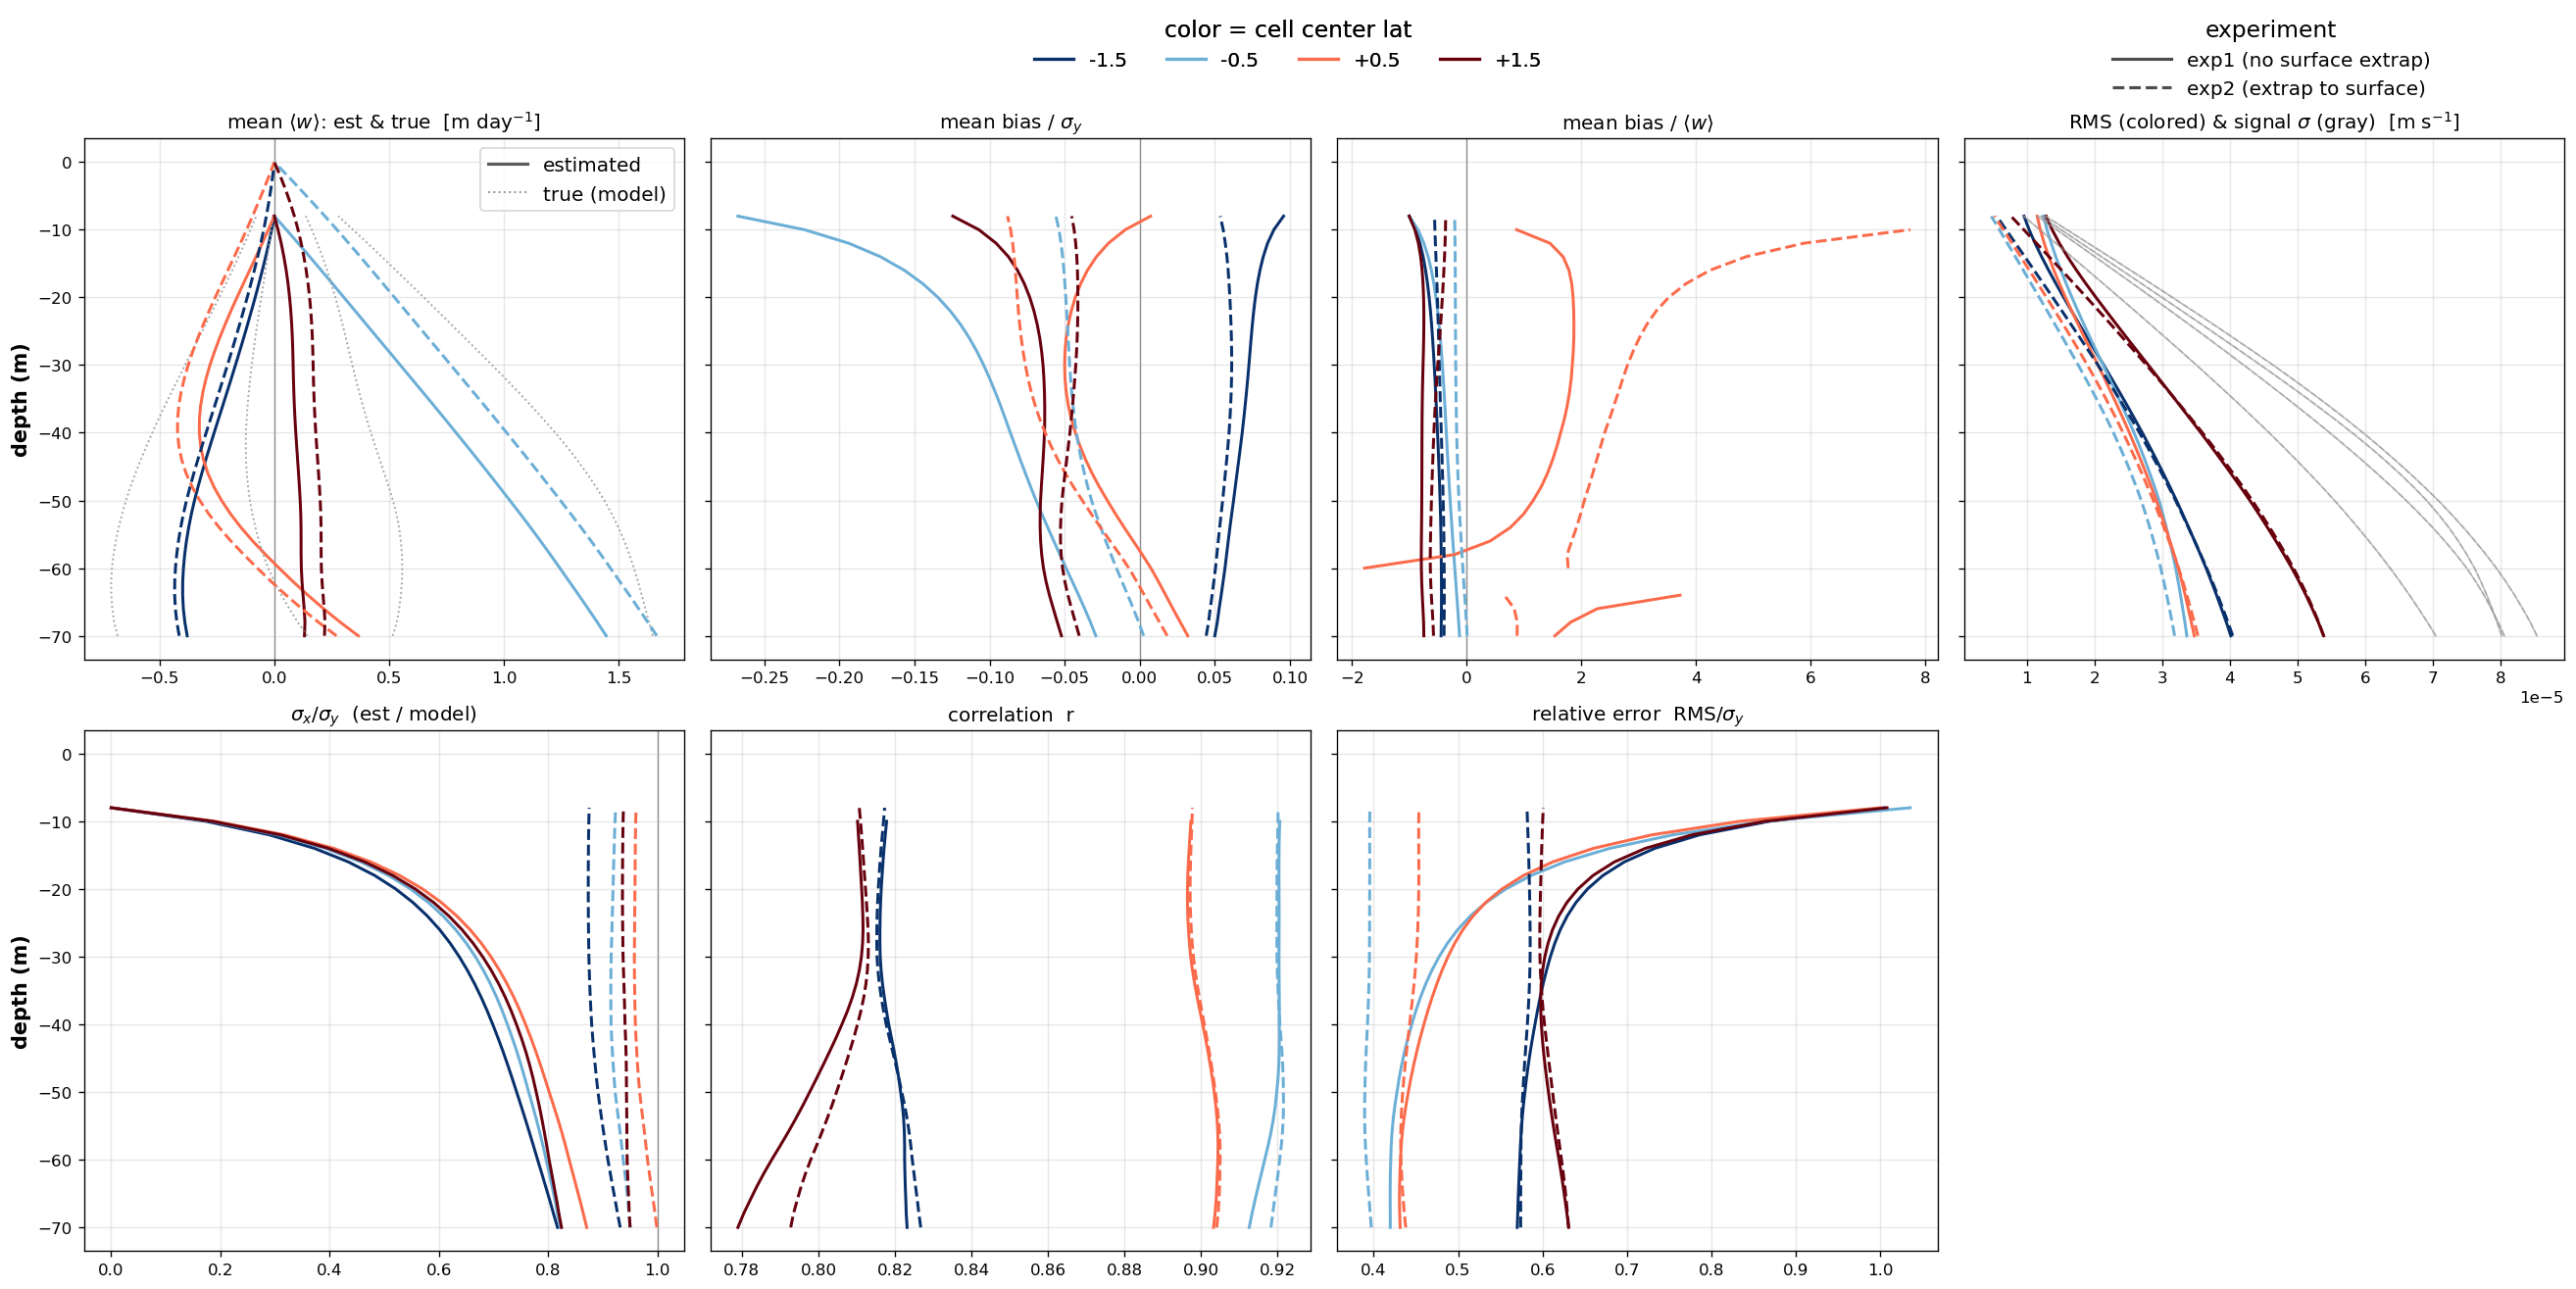

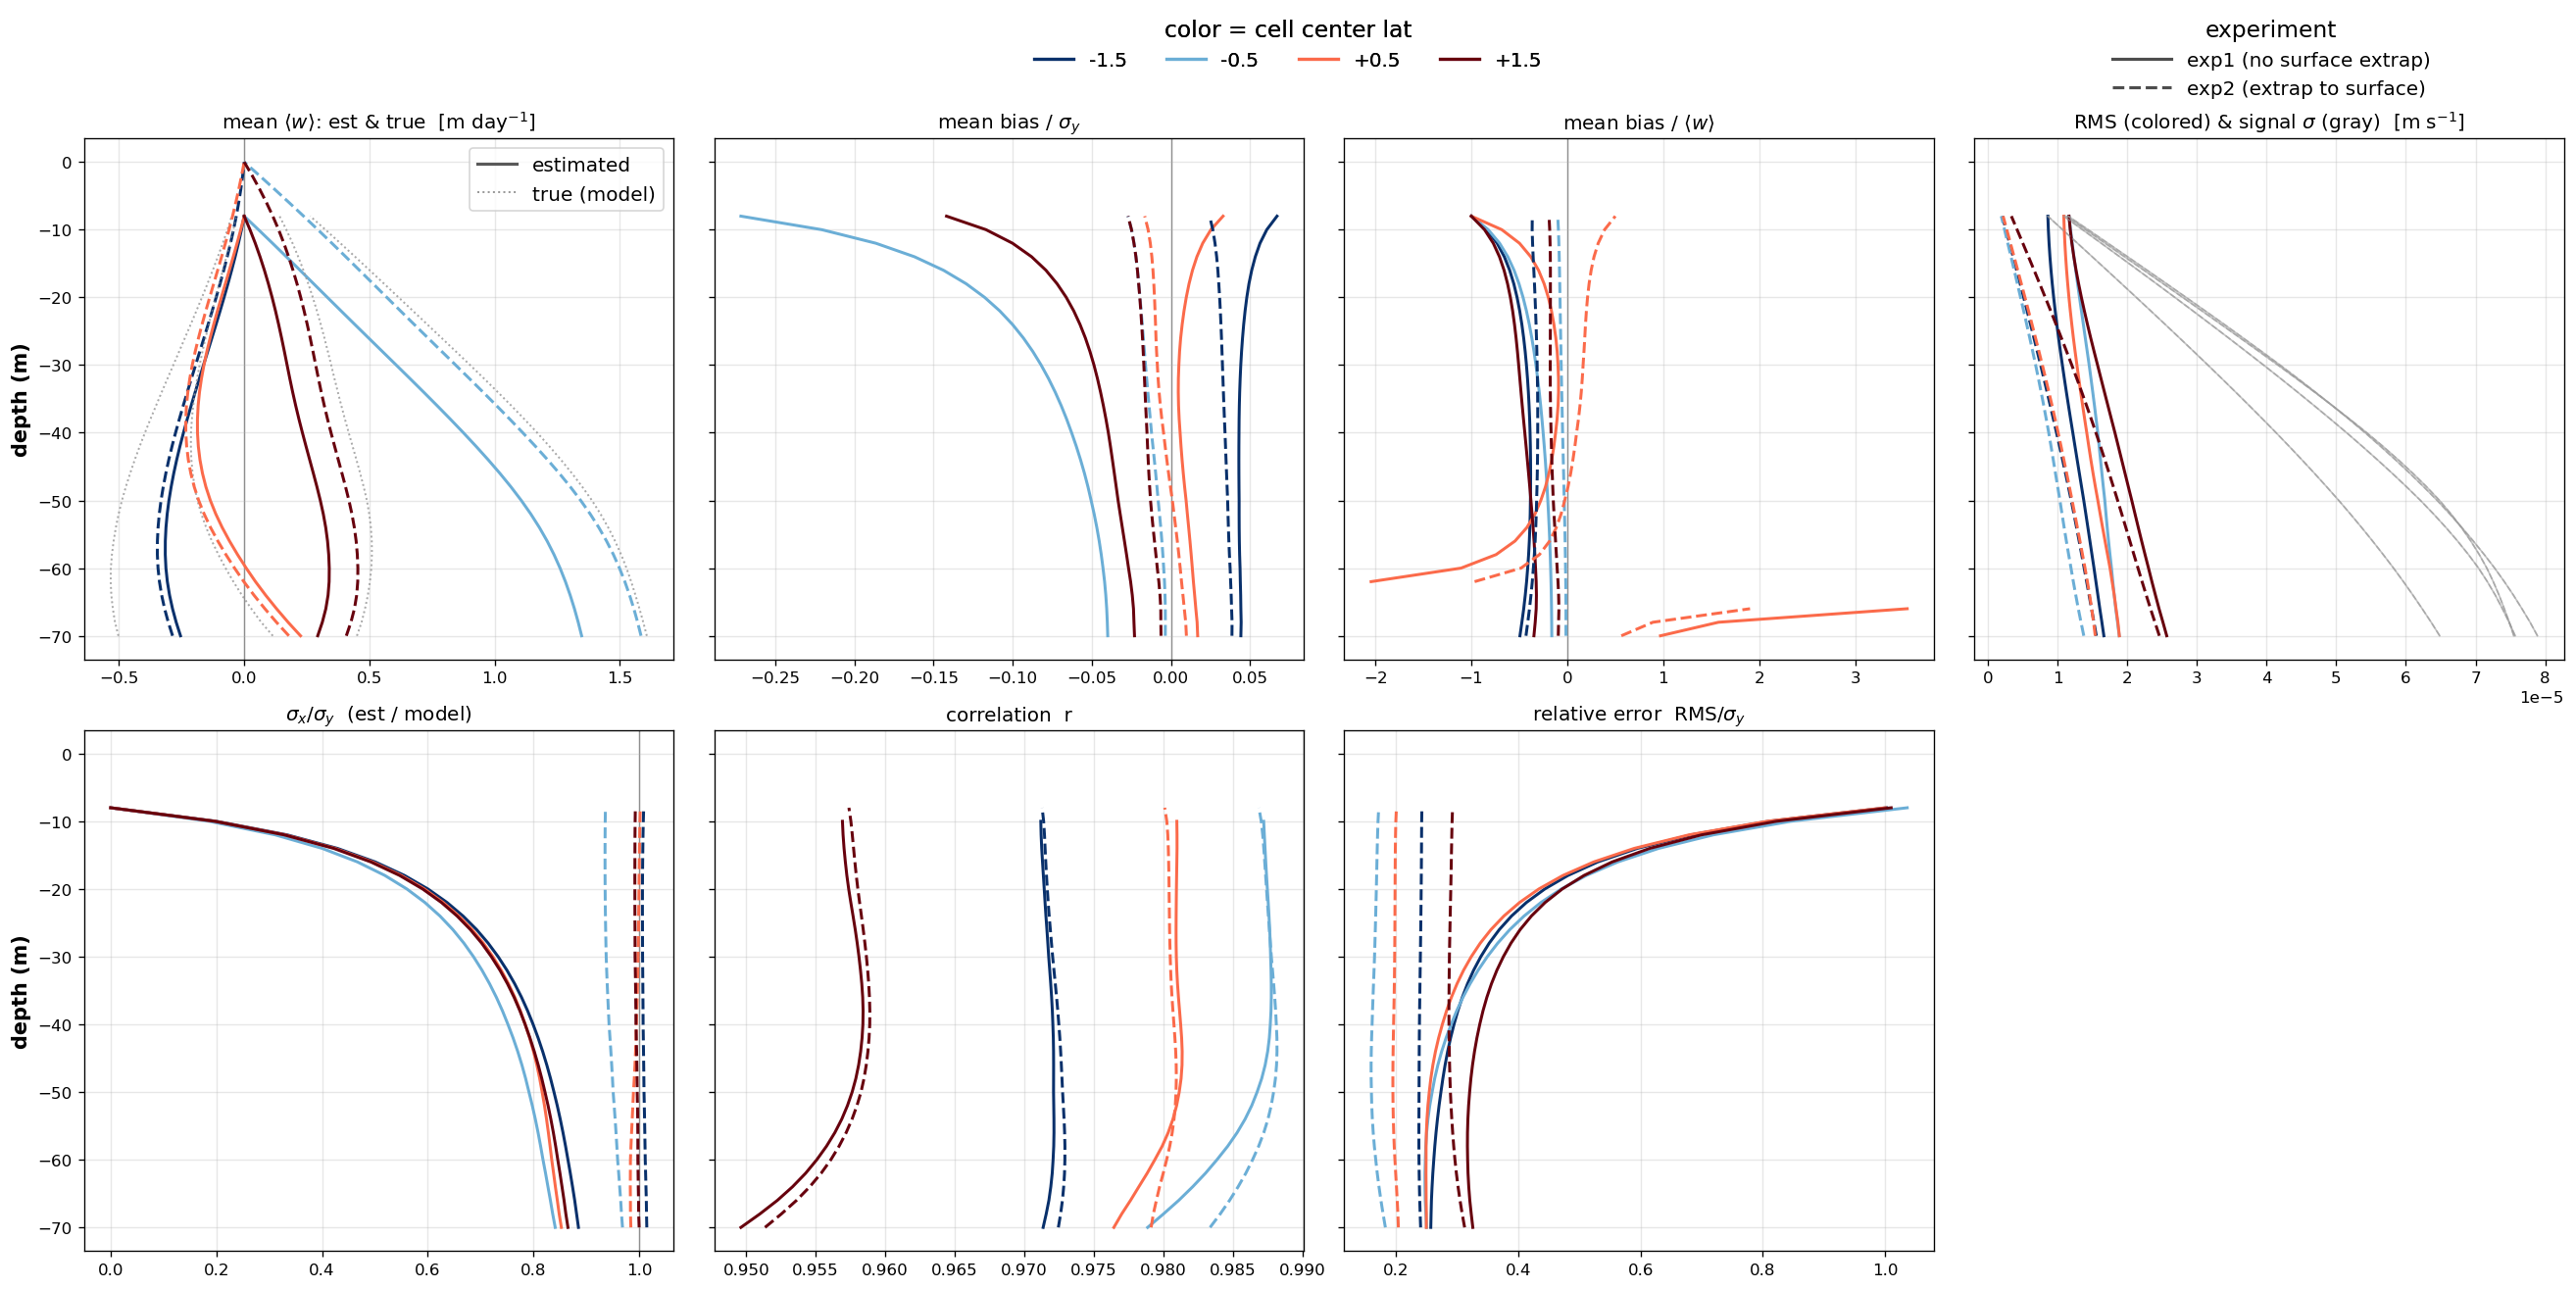

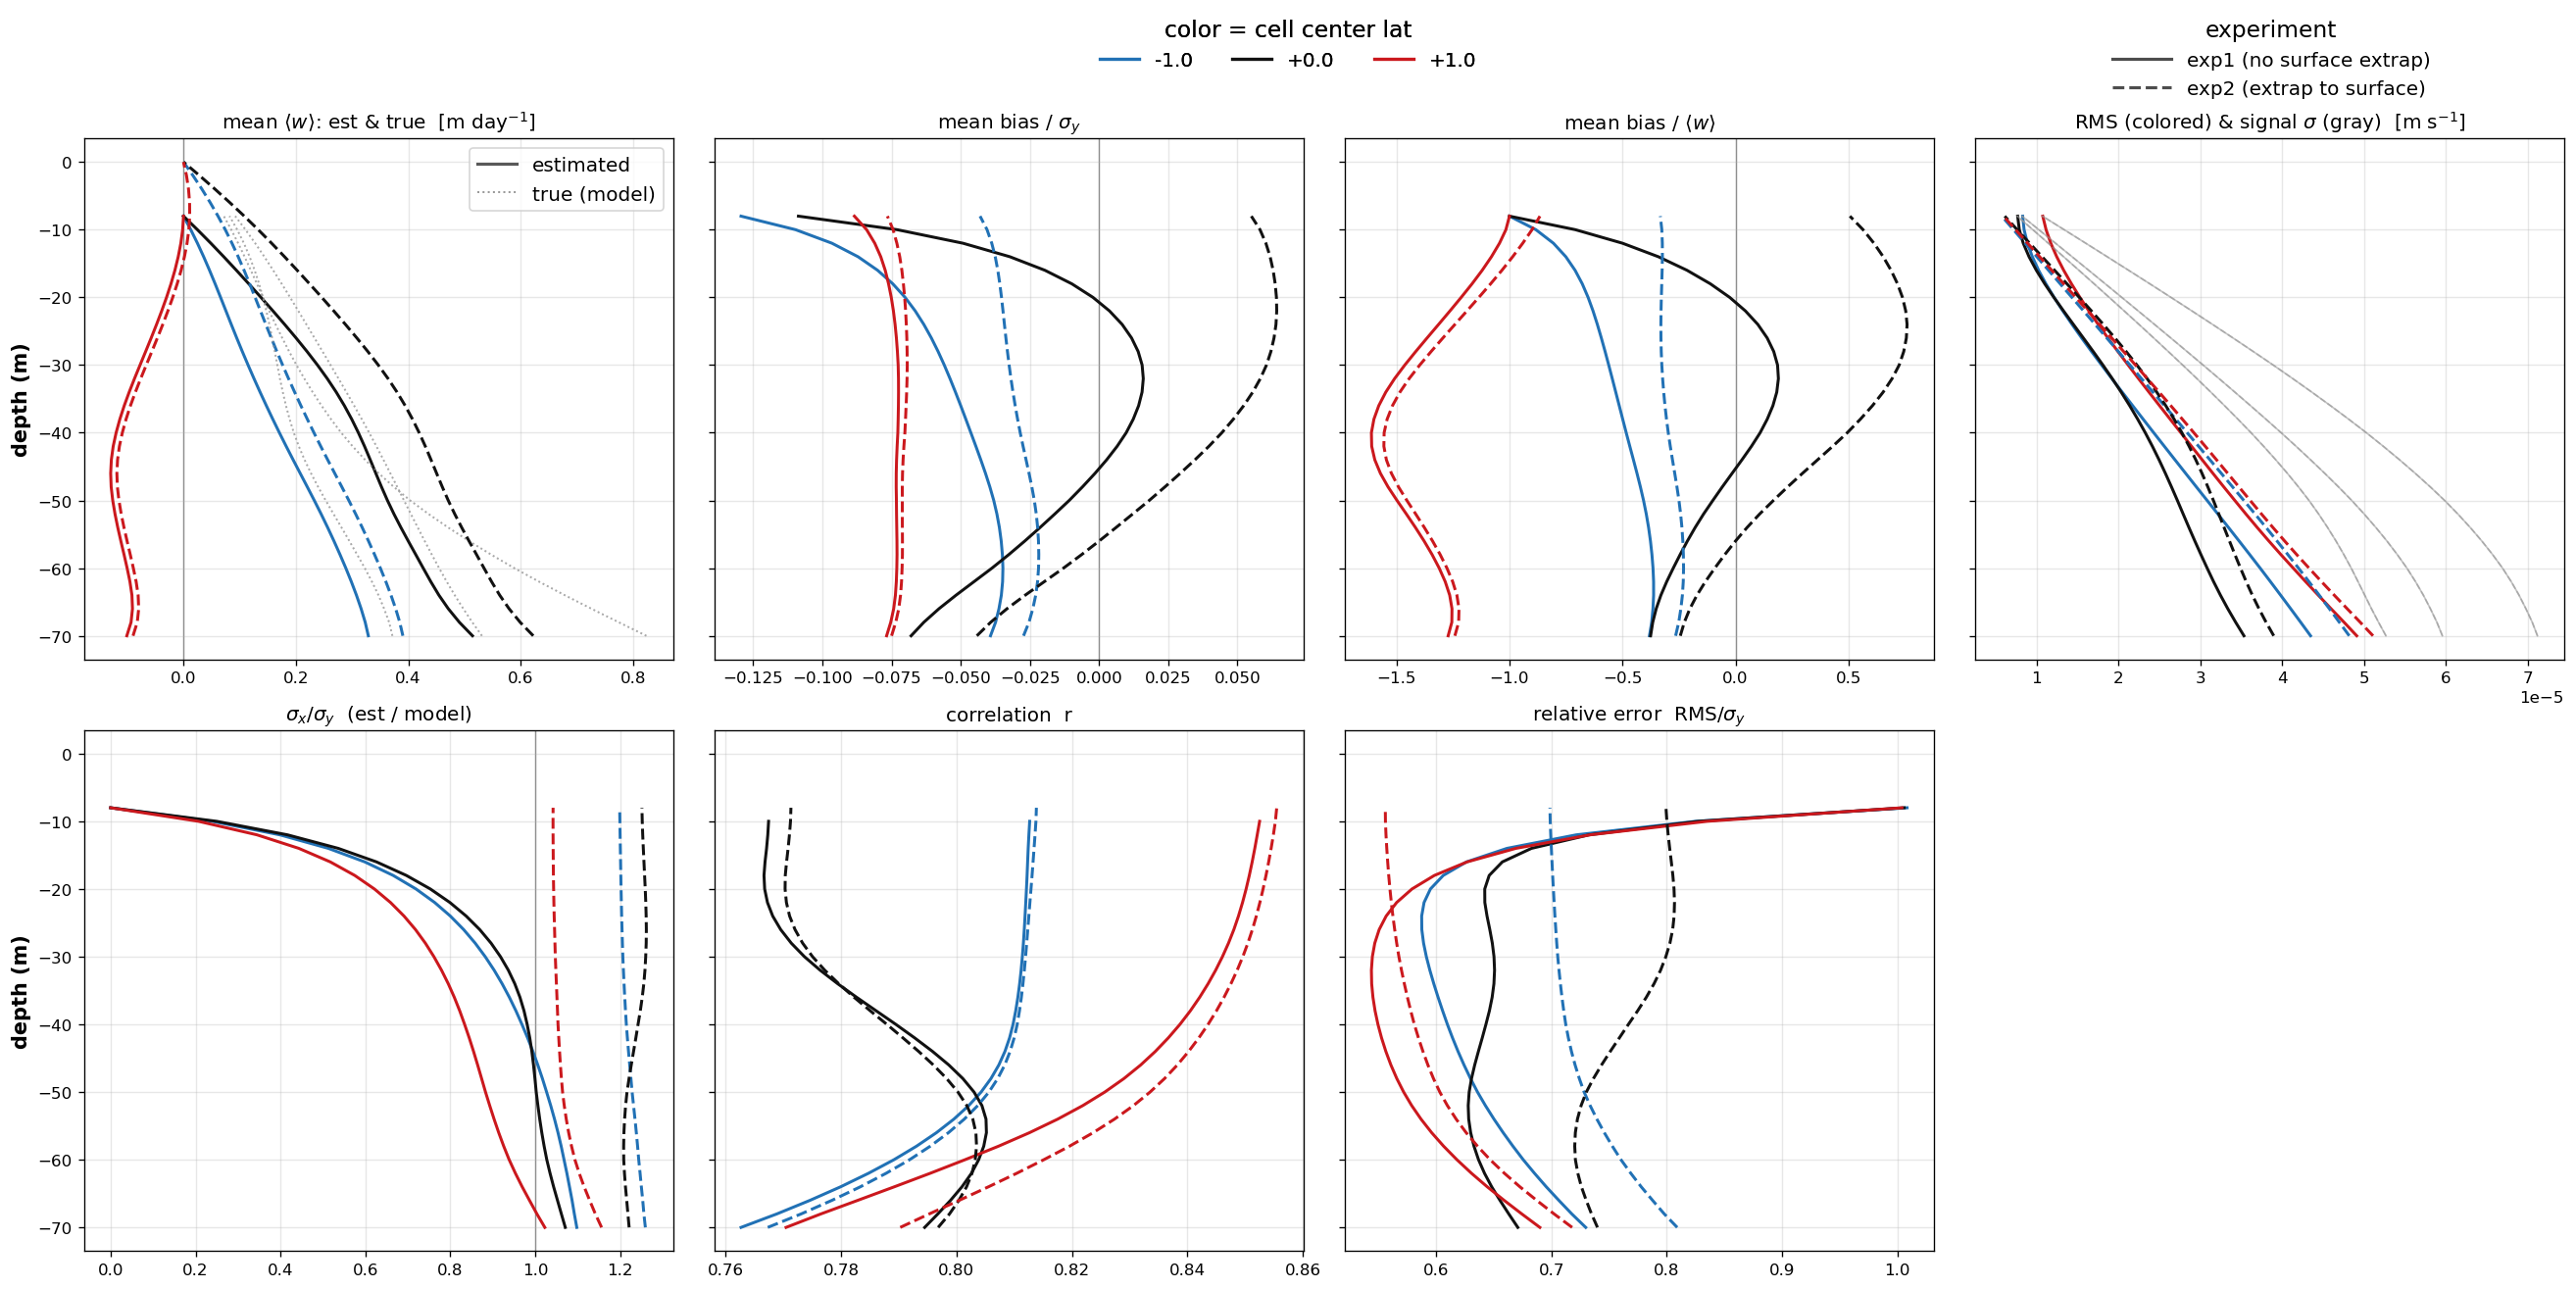

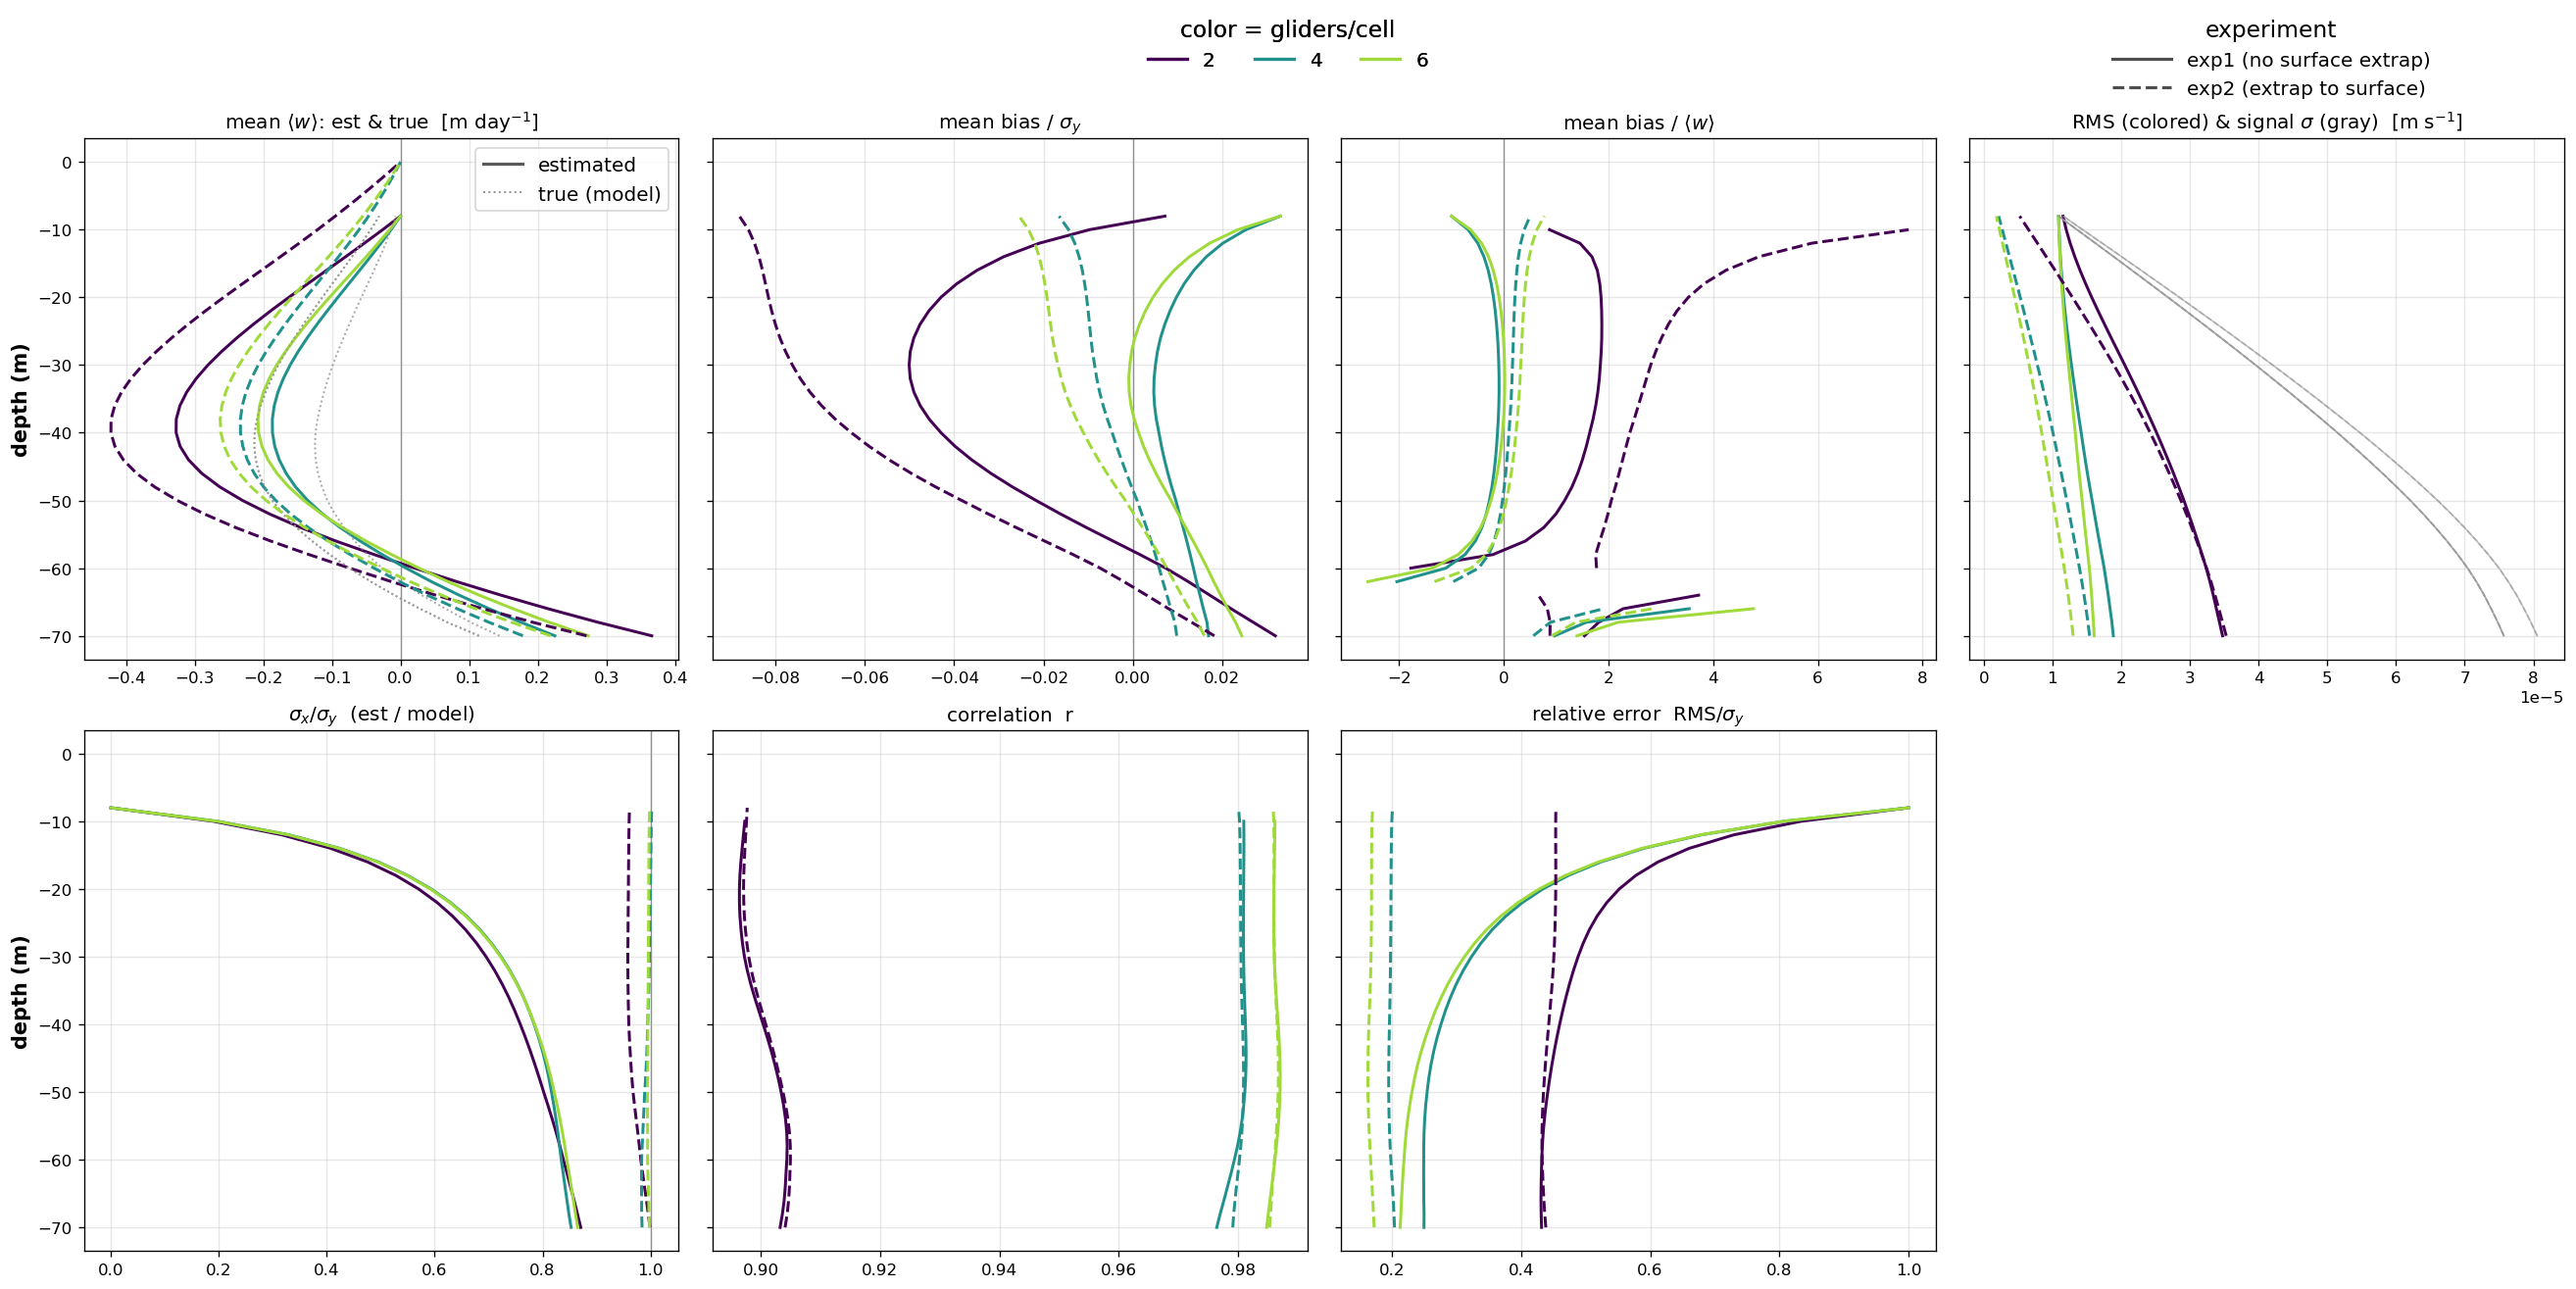

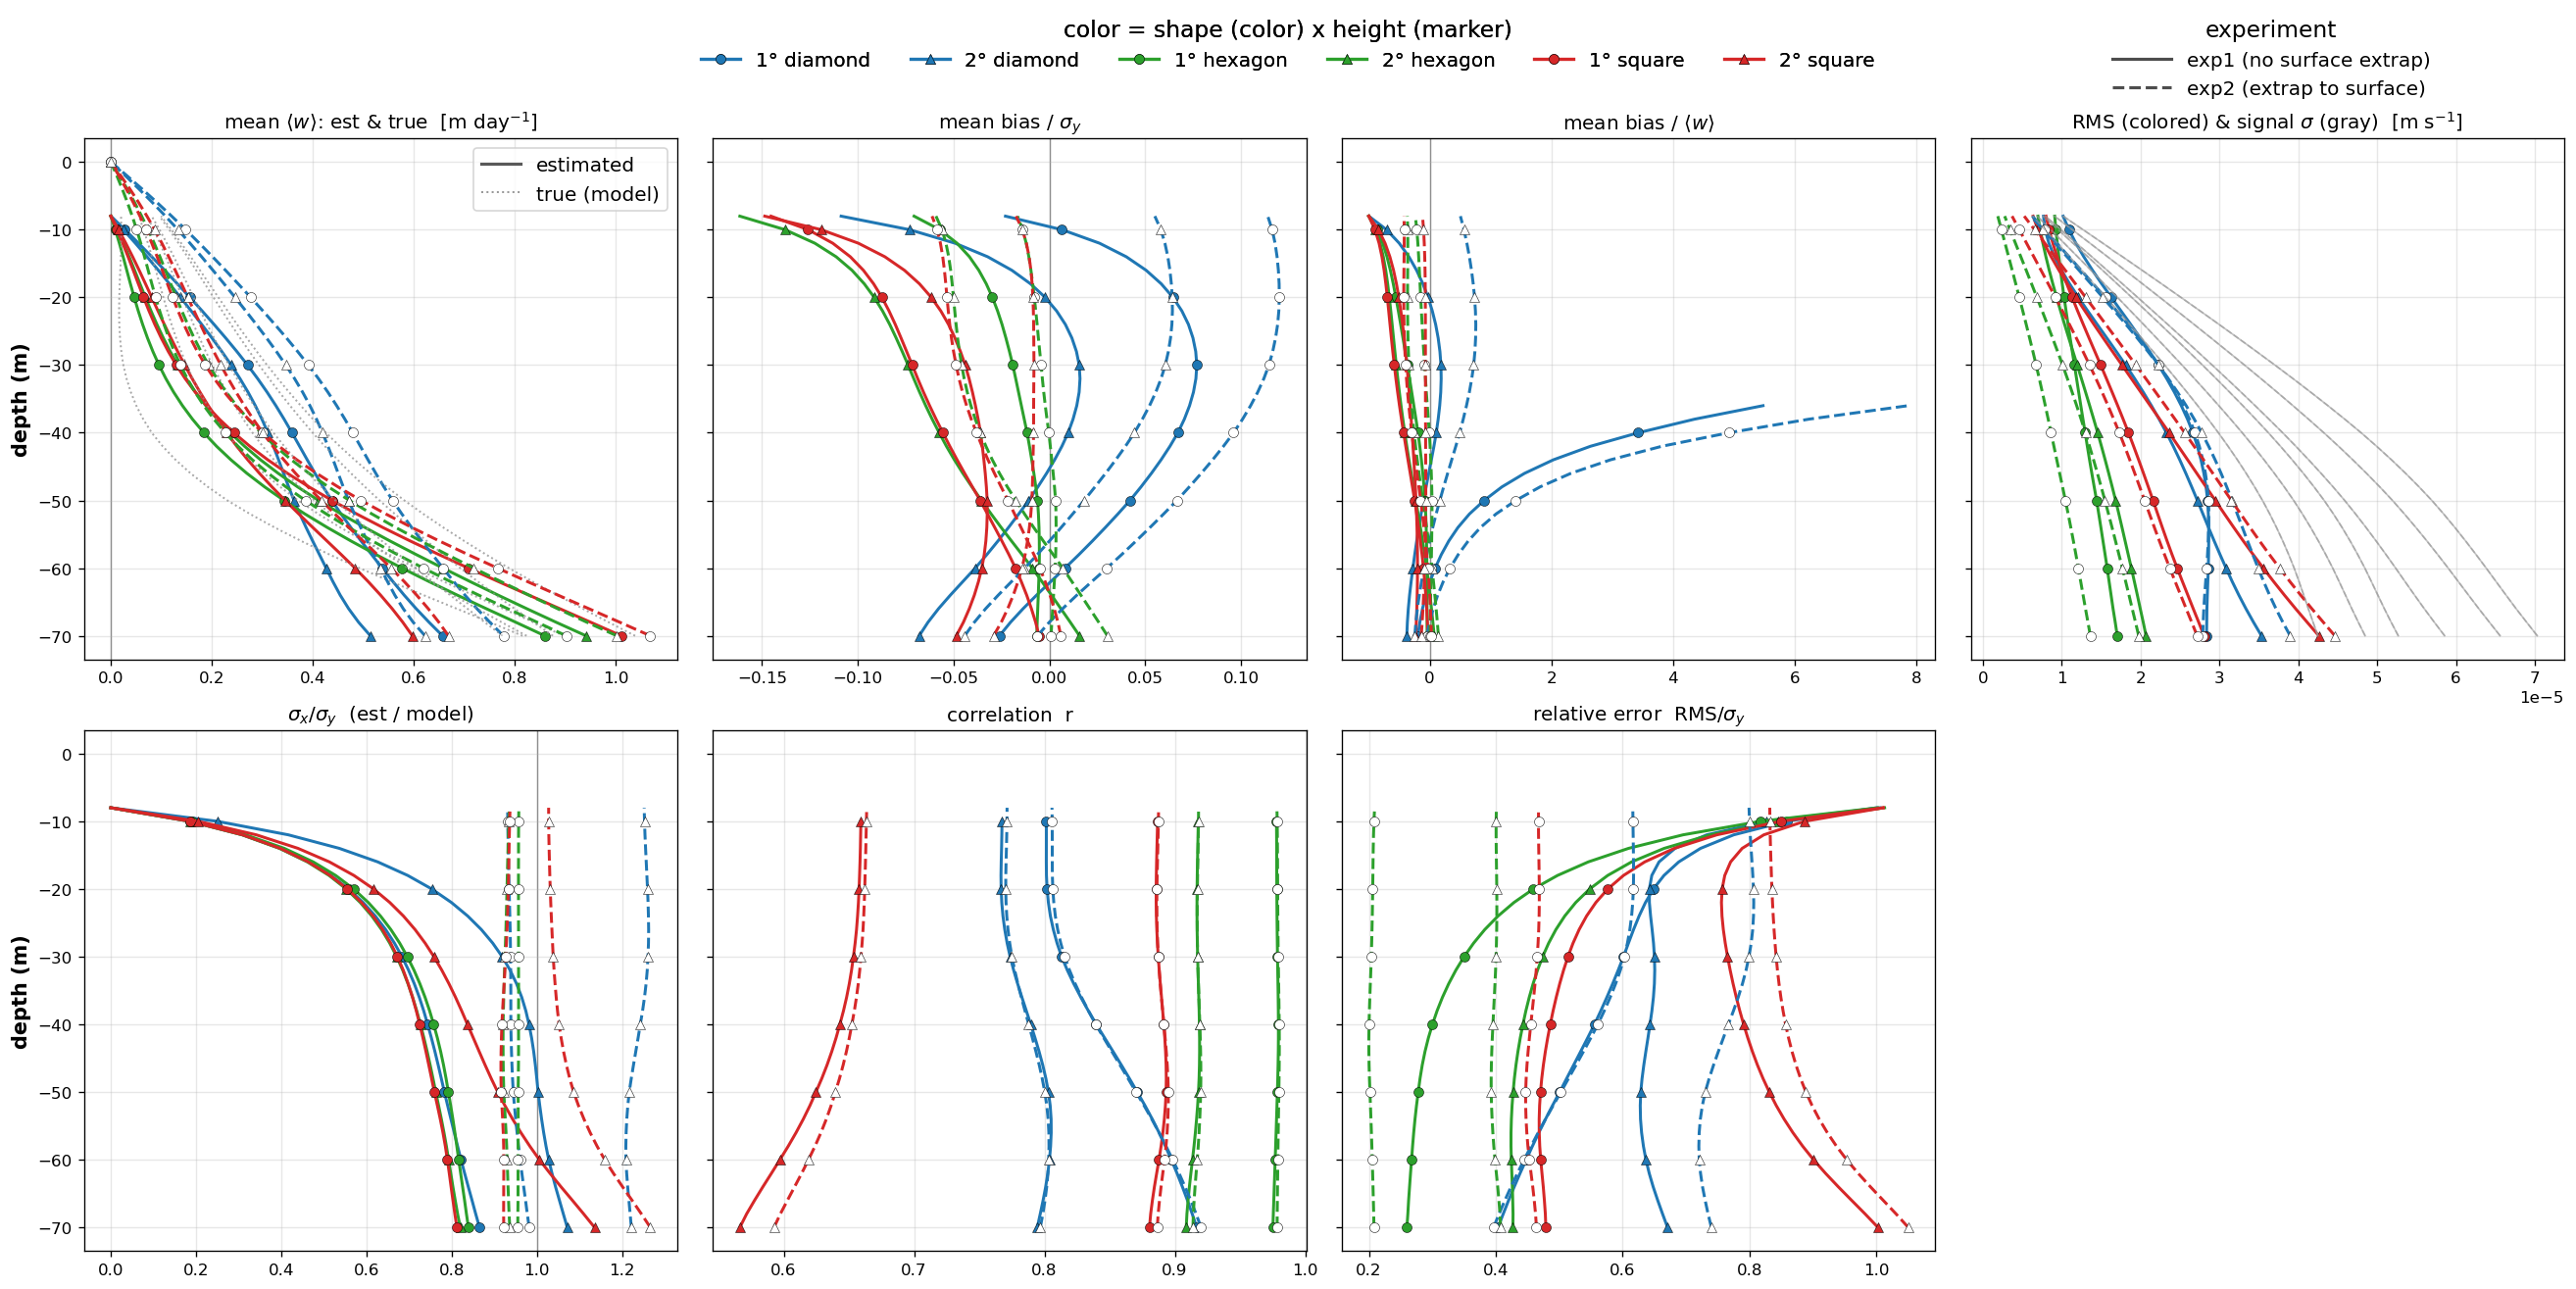

In [5]:
sft.make_fig5_compare(M, OUTDIR, load_cell)

## Figure 6 - metric-change heatmaps (exp2 - exp1 at a glance)

The fig6 "colored squares" from each experiment's summary.ipynb, differenced
so the effect of surface extrapolation is visible across every config in one
view. Rows = estimate cell (pattern @ center latitude), columns = glider lon
offset (array width). Each panel is oriented so **teal = exp2 better, brown =
exp2 worse**: RMS/sigma and |bias|/sigma use exp1 - exp2 (positive = exp2
smaller), correlation uses exp2 - exp1 (positive = exp2 higher). Descriptive
only - shows where the surface-extrapolation choice matters.

**Figures 6a-6d** repeat this change grid one method at a time (same split as fig2a-2d / fig5a-5d): 6a shift, 6b equator 3-cell, 6c density, 6d equator single-cell. Each sub-figure auto-scales its own color range.

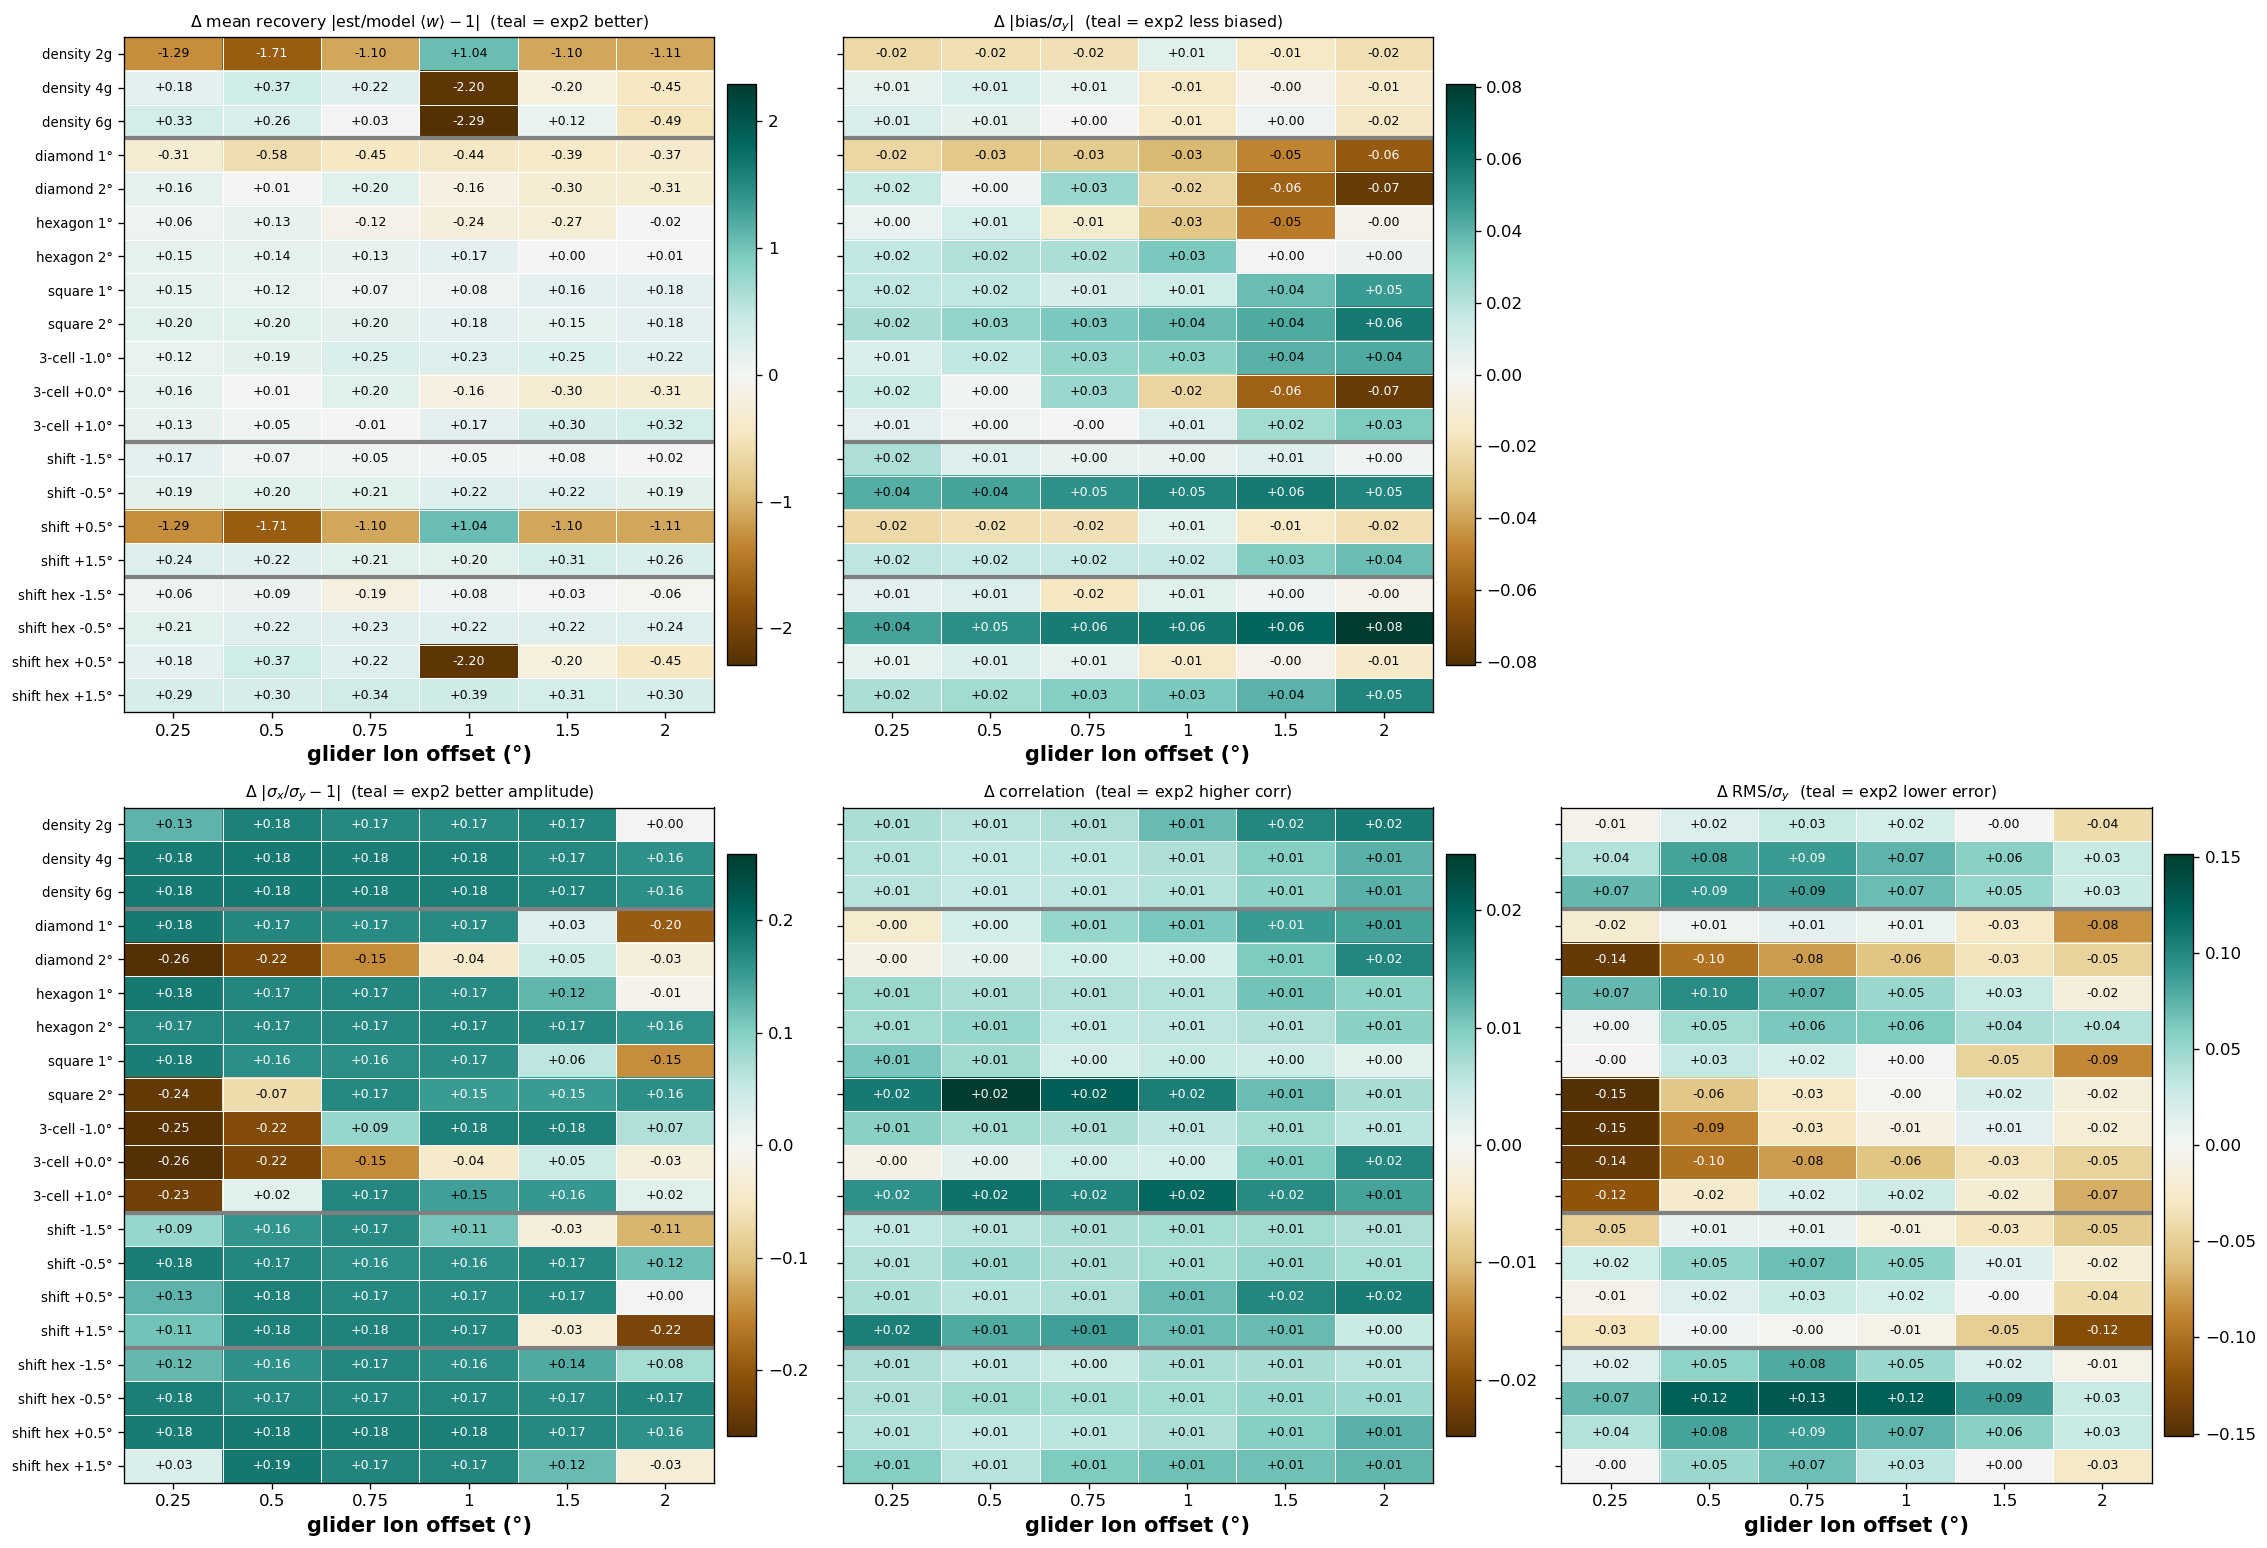

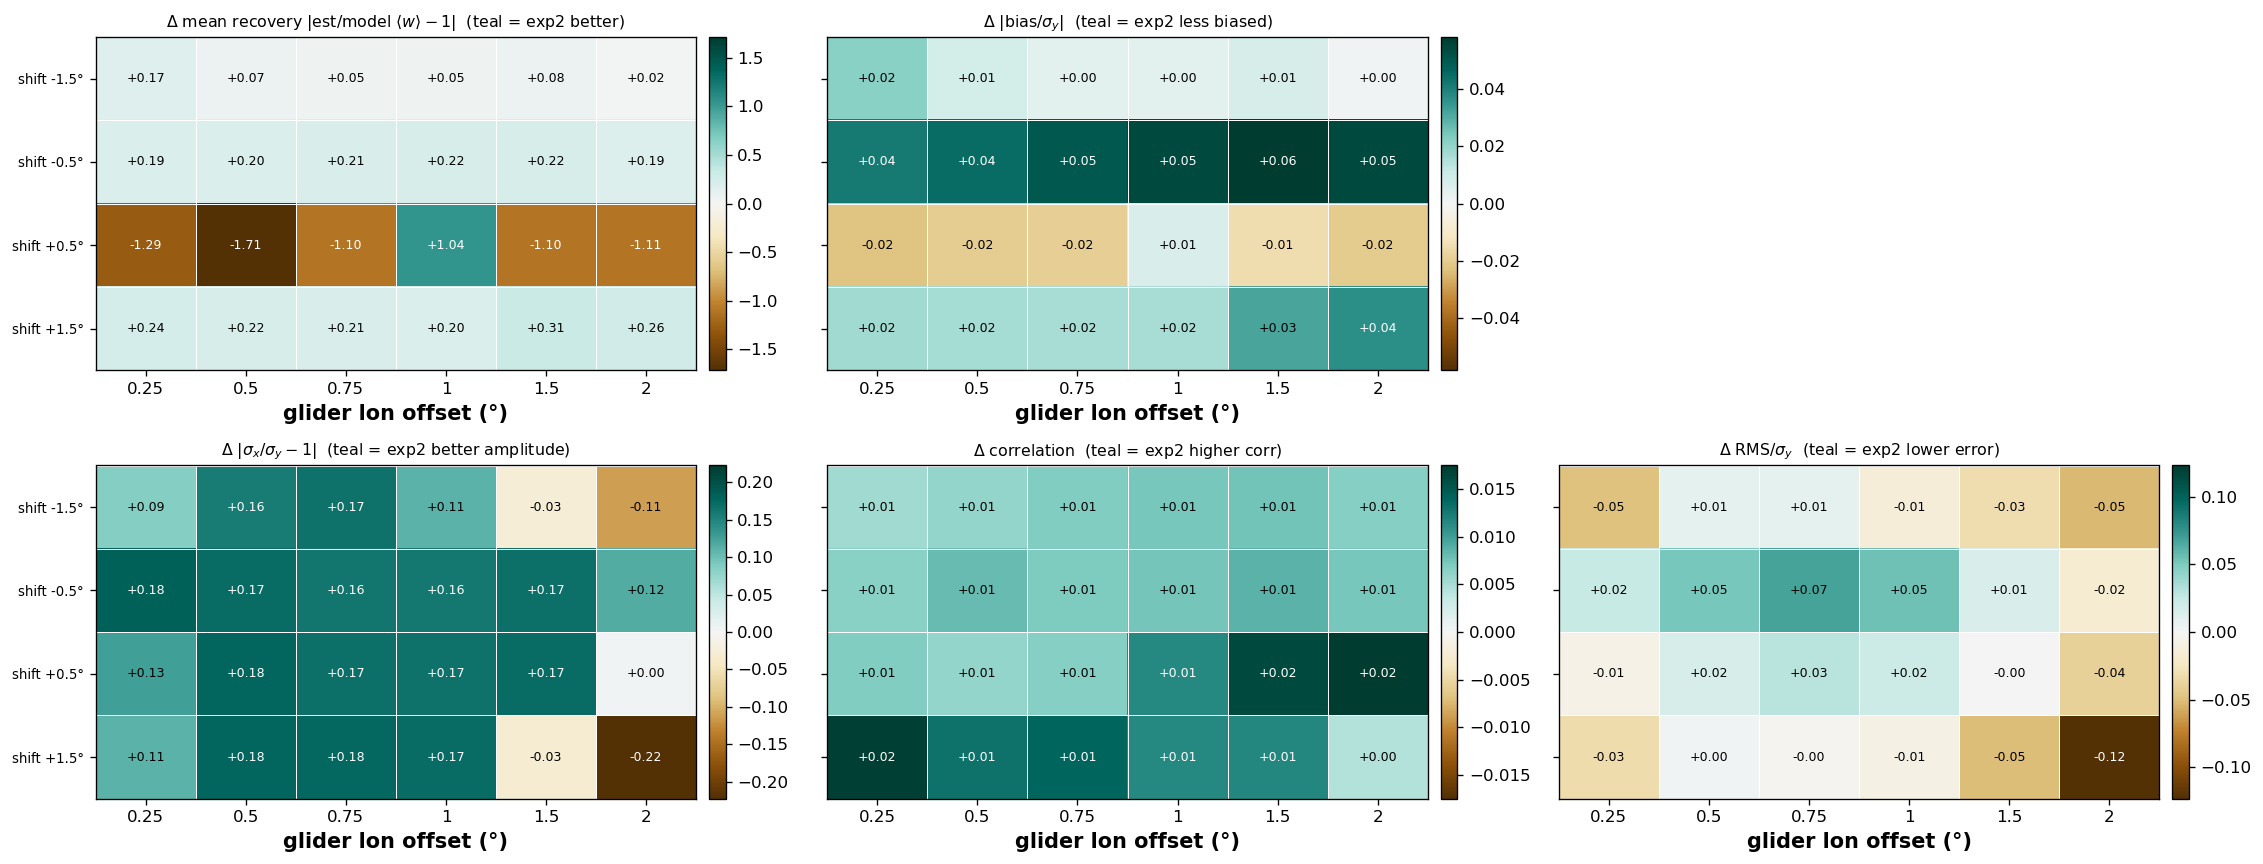

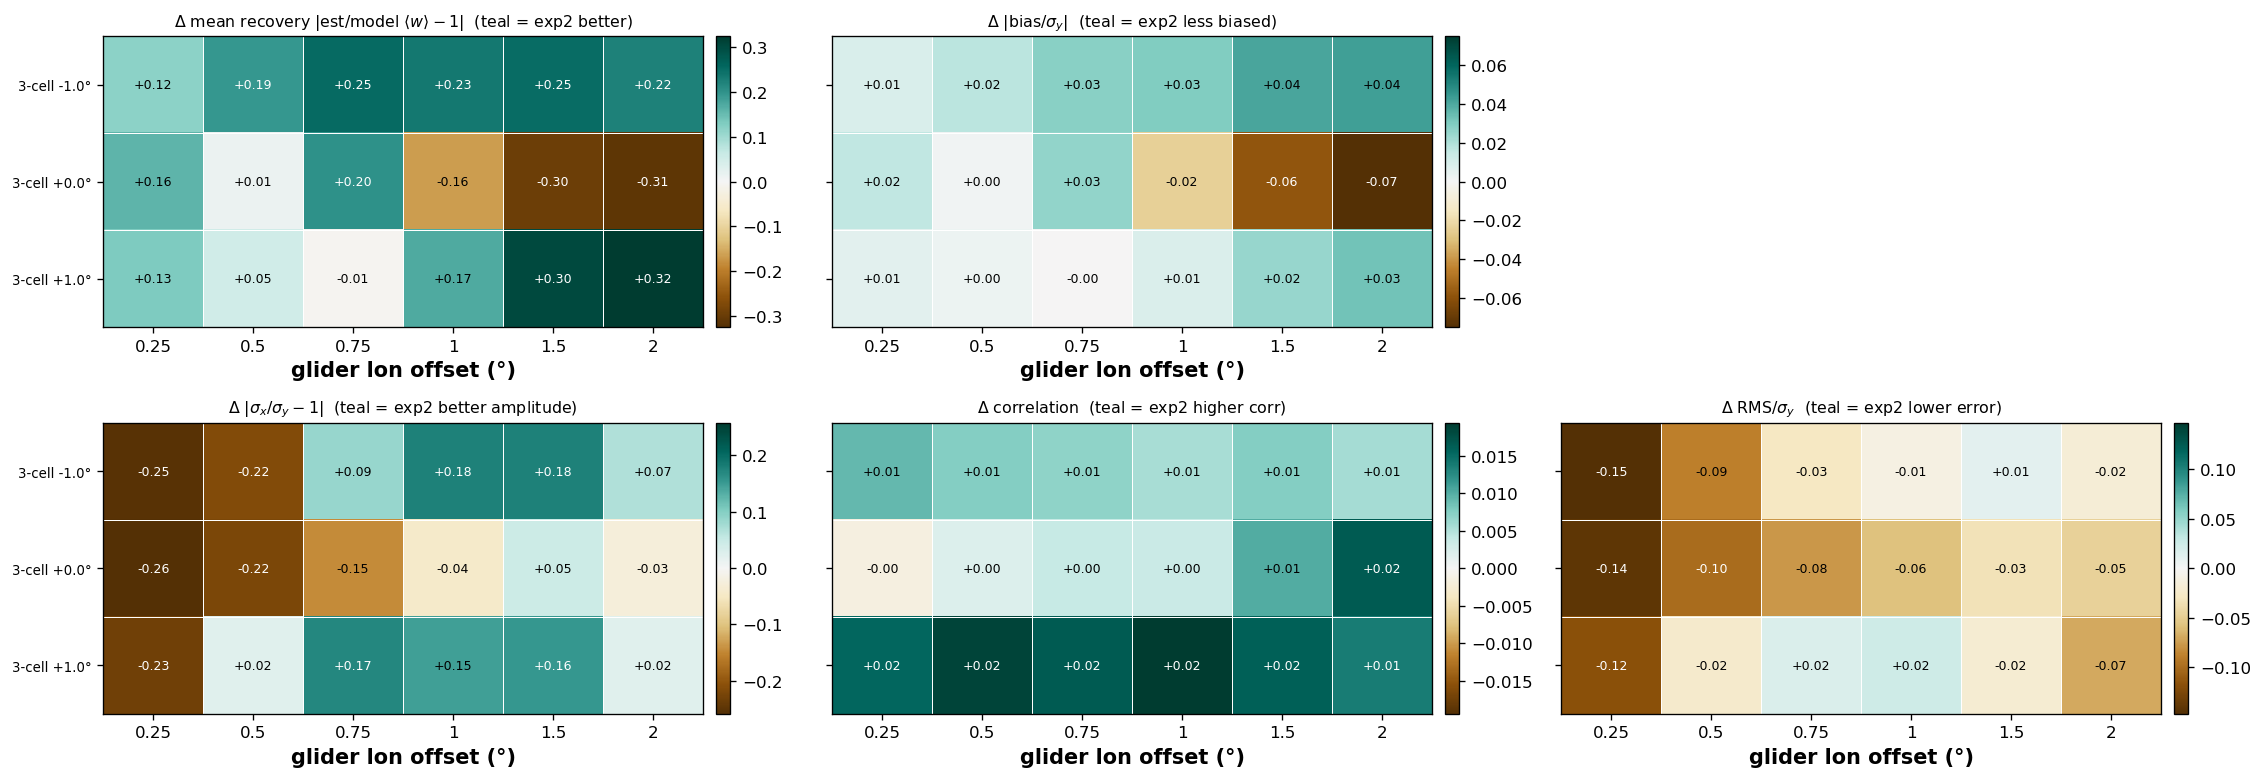

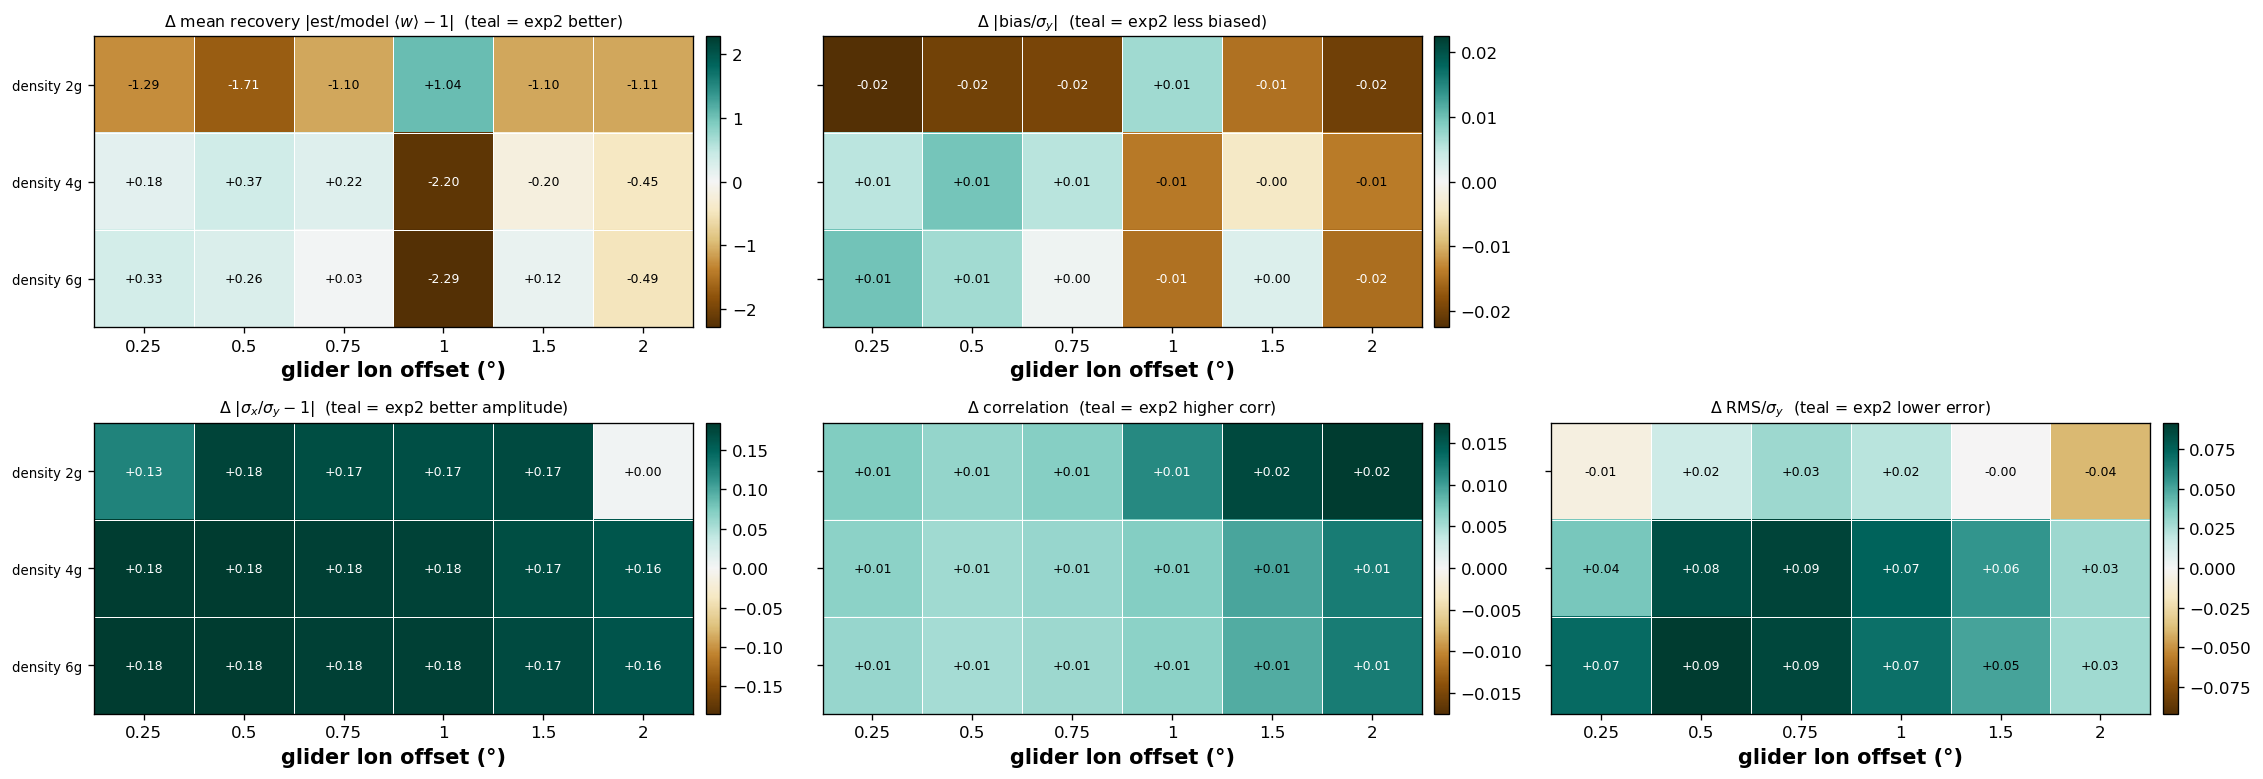

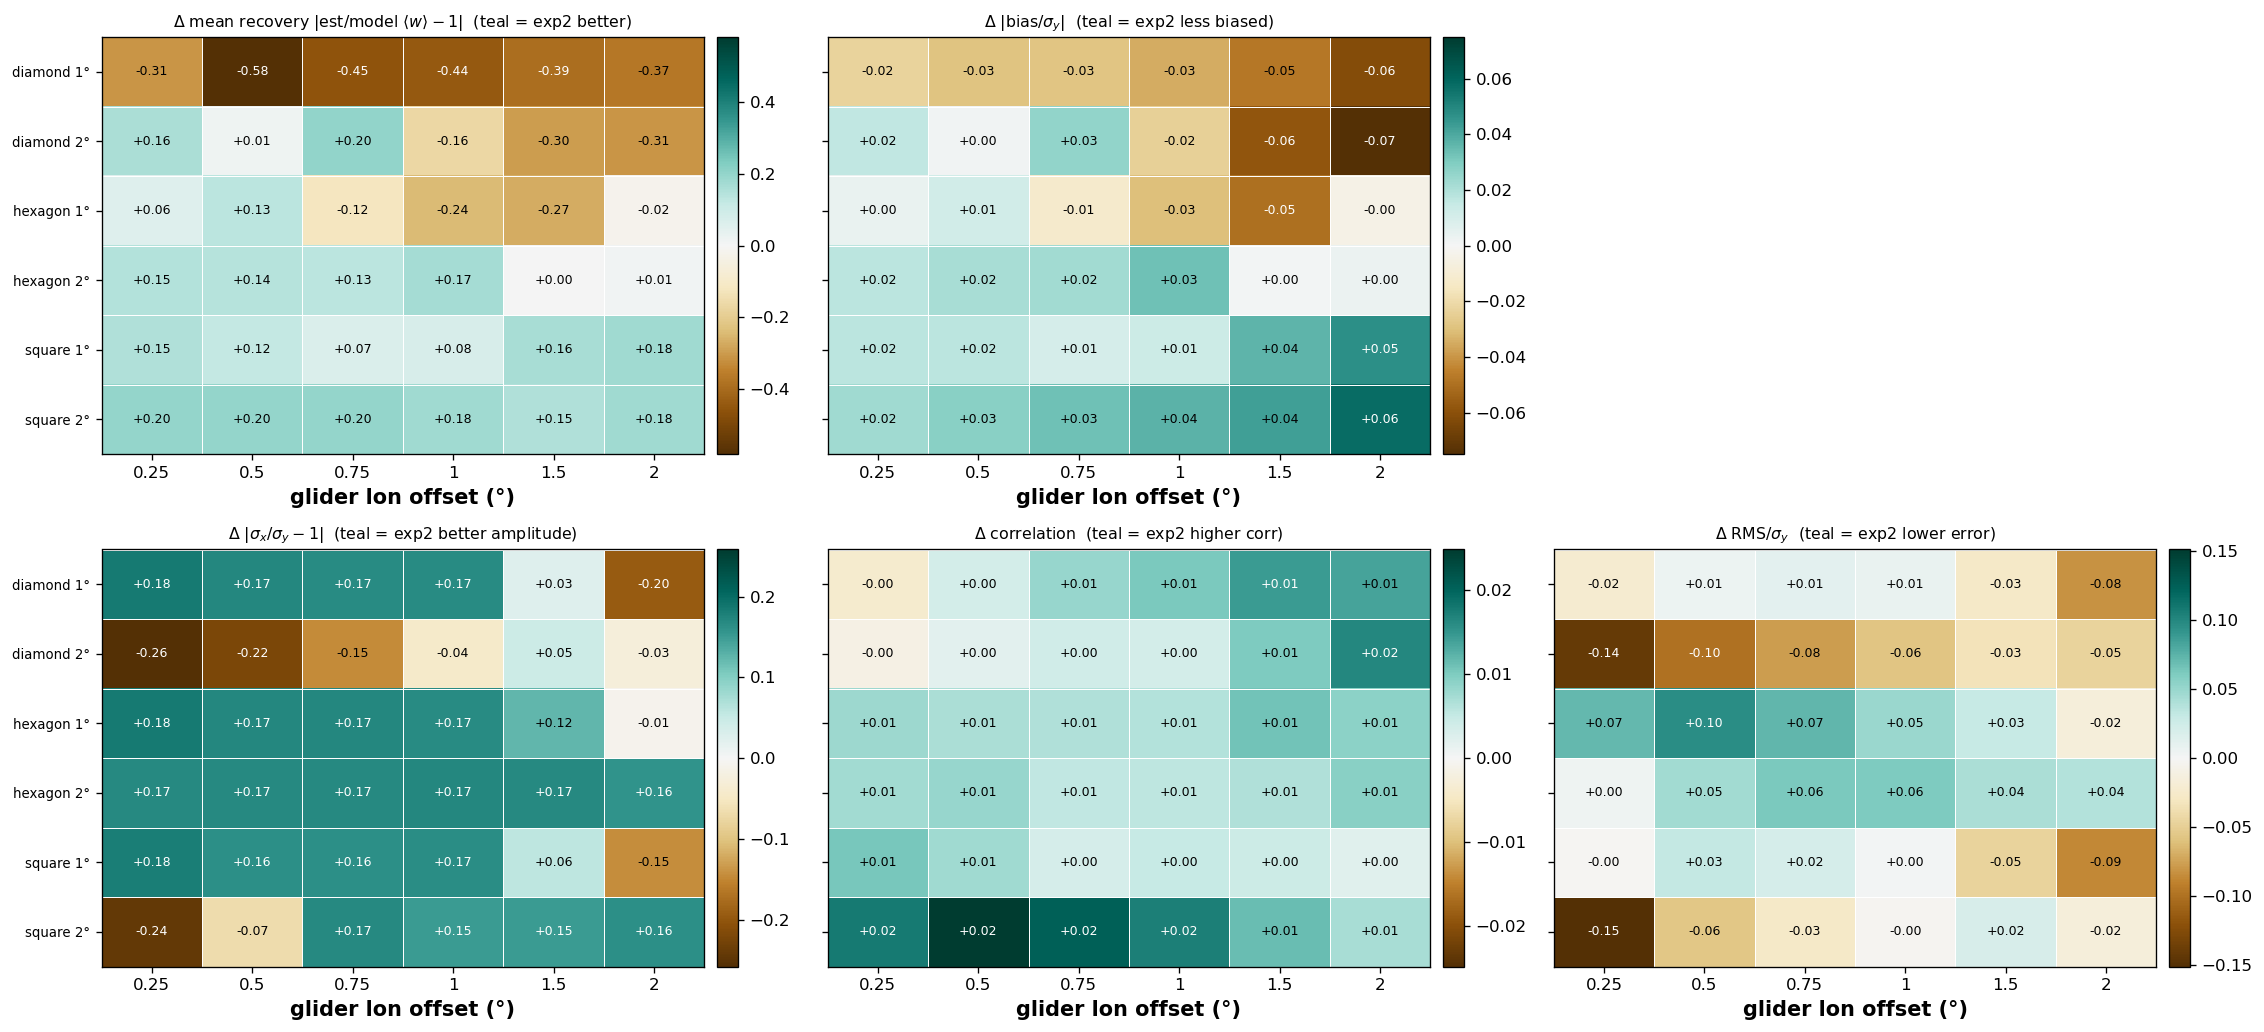

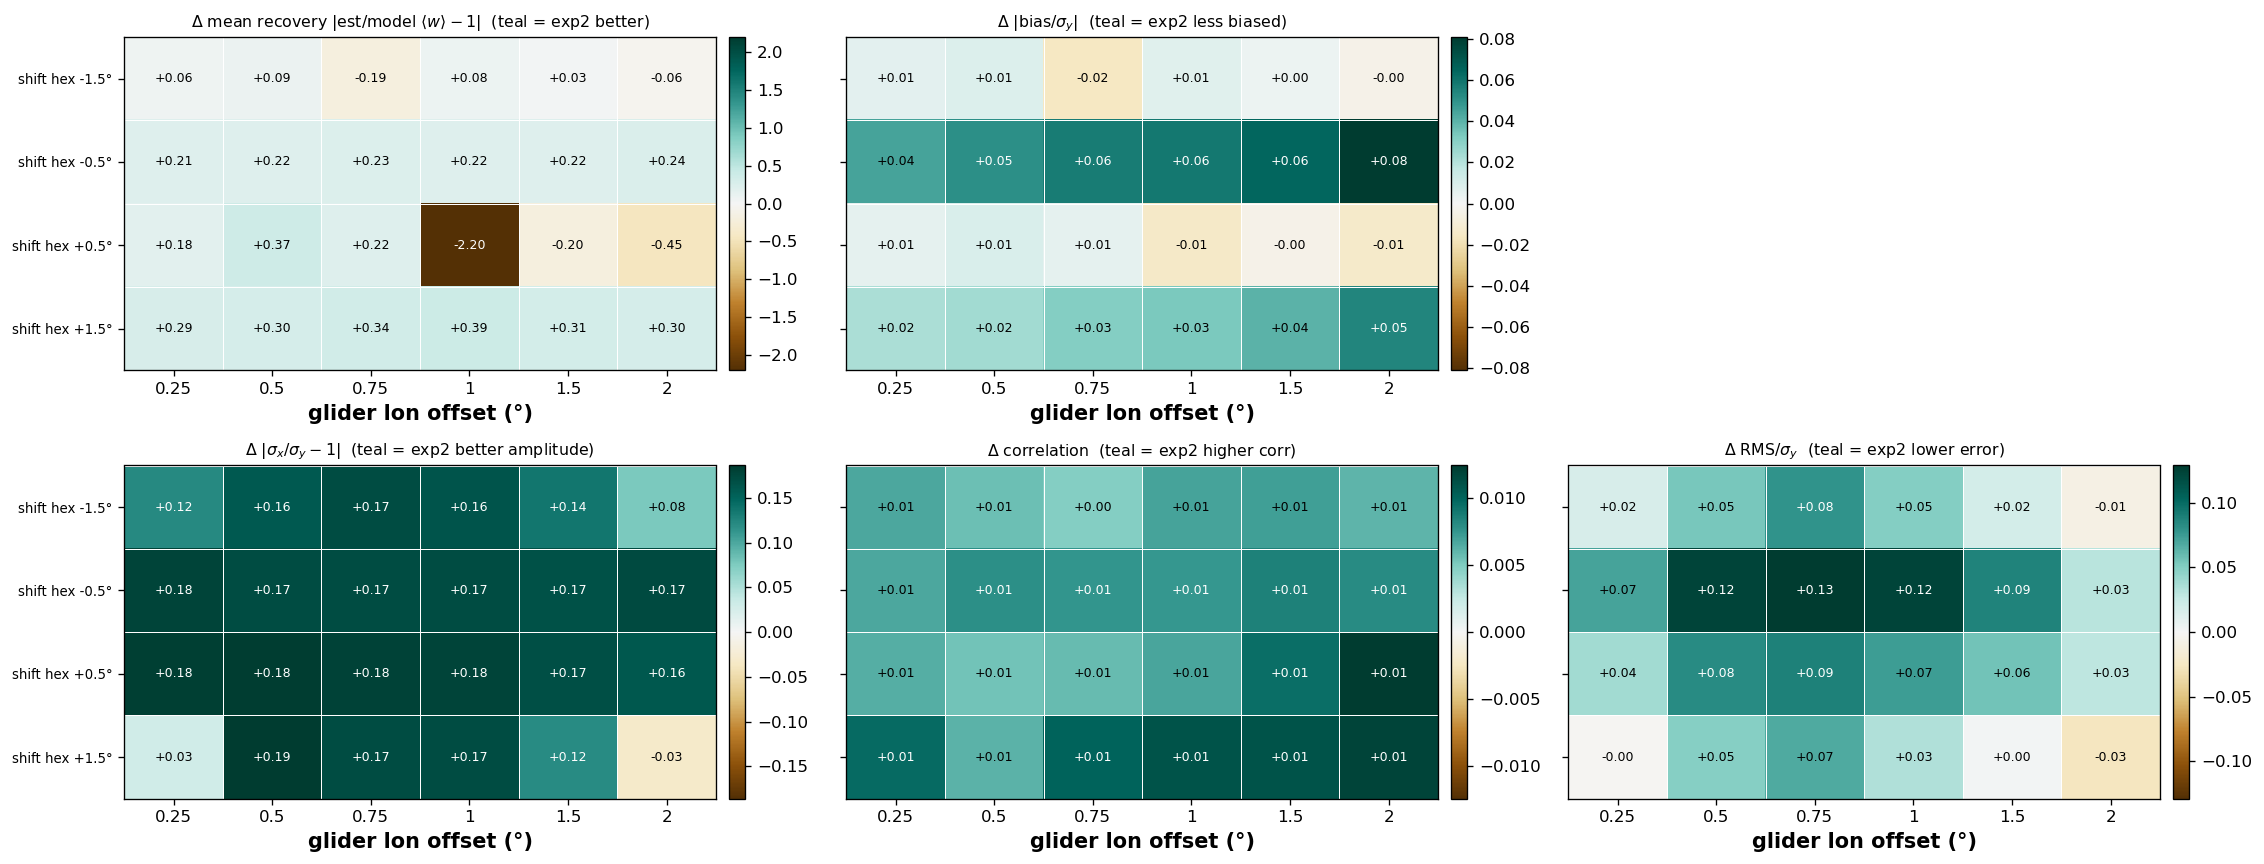

In [6]:
sft.make_fig6_compare(M, OUTDIR)